Loaded closes: T=2629, N=5, pairs=['EUR_USD', 'USD_JPY', 'GBP_USD', 'USD_CNH', 'USD_CAD']
Finished GEDMD forecasting (Scenario 1 run).

=== SIGNAL QUALITY: PRECISION & RECALL VS THRESHOLD (Scenario 1) ===
 Threshold_%  TP   FP   FN    TN  Precision_%  Recall_%
           1 868 2225 2758  7294    28.063369 23.938224
           2 250 1090 1596 10209    18.656716 13.542795
           3  82  445  765 11853    15.559772  9.681228
           4  43  211  359 12532    16.929134 10.696517
           5  15  127  164 12839    10.563380  8.379888
           6   6   89   78 12972     6.315789  7.142857
           7   4   65   32 13044     5.797101 11.111111
           8   1   37   16 13091     2.631579  5.882353
           9   0   18    7 13120     0.000000  0.000000
          10   0    6    3 13136     0.000000  0.000000

=== TRADING PERFORMANCE (YIP-STYLE, LONG-ONLY, τ=20, Scenario 1) ===
 Threshold_%  GEDMD_AnnRet_%  GEDMD_AnnVol_%  GEDMD_Sharpe  Benchmark_AnnRet_%  Benchmark_AnnVol_%  Benchmark

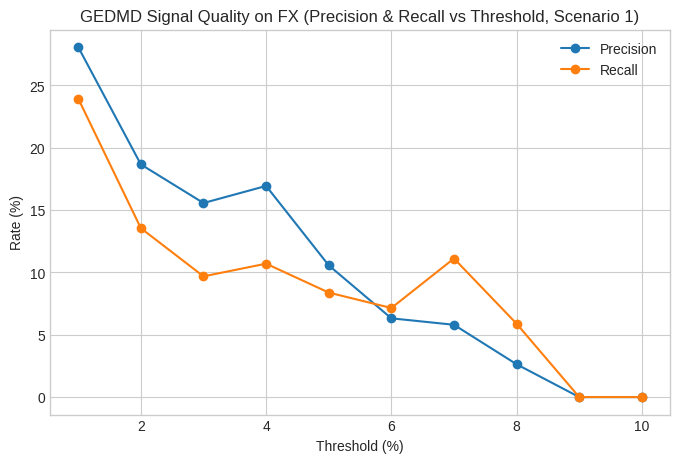

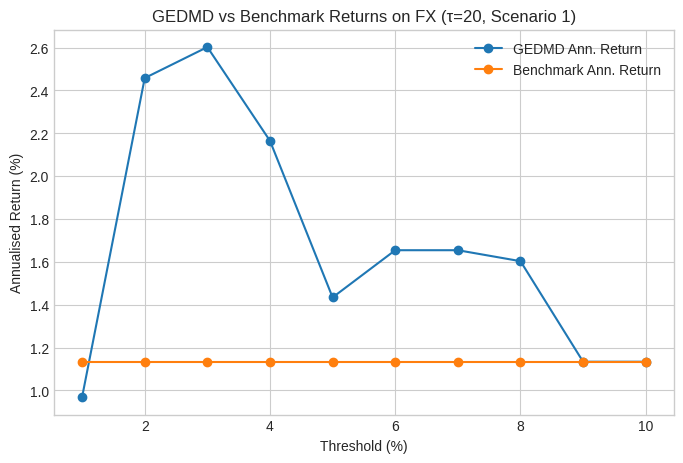

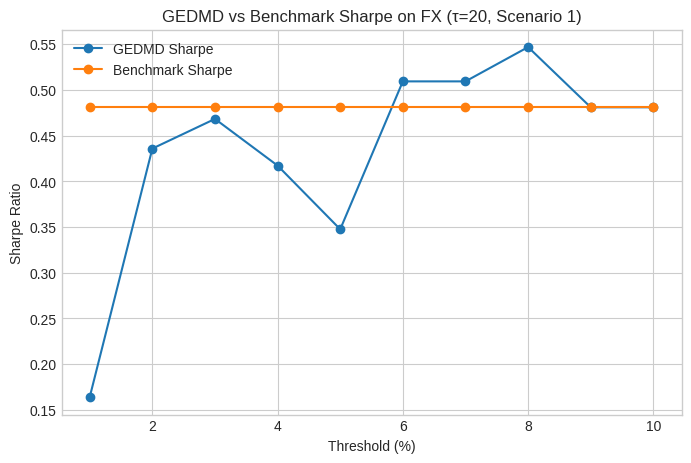

In [12]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')  # keep runtime output clean; nothing critical is being hidden

# ============================================================
# SCENARIO 1 PIPELINE (YIP-STYLE SPEC ON FX DATA)
#
# Notebook logic (for the examiner / future me):
#   - This run corresponds to Scenario 1 in the thesis:
#       "Yip-style GEDMD specification, applied to FX daily closes".
#   - The same core code (GEDMD_Core, forecasting, evaluation, plots)
#     is reused for Scenario 2 and Scenario 3; only the hyperparameters
#     and/or the λ-rule are changed in separate runs.
# ============================================================

# ------------------------------------------------------------
# 0. GLOBAL PARAMETERS – SCENARIO 1 SETTINGS
# ------------------------------------------------------------
TAU = 20                 # τ-step forecast horizon (in bars)
L = 30                   # length of the Hankel / delay embedding
M = 120                  # rolling window size used to fit each GEDMD operator
K_NEIGHBOURS = 5         # maximum number of neighbours kept in the correlation graph

CONFIDENCE = 0.99        # confidence level used in Fisher-z intervals for correlations
C_THRESHOLD = 0.05       # minimum lower-bound on |rho| to treat a link as "real"

TARGET_COND = 100.0      # target condition number when choosing the Tikhonov λ

THRESHOLDS = np.arange(0.01, 0.11, 0.01)  # event thresholds: 1% … 10% τ-horizon "up" moves

# ============================================================
# 1. LOAD FX PANEL (COMMON ACROSS ALL SCENARIOS)
# ============================================================
# Expected CSV format:
#   - First column: timestamp
#   - Remaining columns: MultiIndex (pair, field), where one field is 'close'
df_raw = pd.read_csv('merged_forex_data.csv', header=[0, 1])

# Some exports repeat "timestamp" as the first data row; if so, drop that row
if str(df_raw.iloc[0, 0]).lower() == 'timestamp':
    df_raw = df_raw.iloc[1:]

# Use the timestamp as the DataFrame index
df_raw.index = pd.to_datetime(df_raw.iloc[:, 0], utc=True)
df_raw = df_raw.iloc[:, 1:]  # drop the original timestamp column from the data

# From the panel we only need close prices for GEDMD
closes = df_raw.xs('close', level=1, axis=1).astype(float).ffill().dropna()
pairs = closes.columns
T, N = closes.shape
print(f"Loaded closes: T={T}, N={N}, pairs={list(pairs)}")

# ============================================================
# 2. GEDMD CORE (SHARED ACROSS SCENARIOS)
# ============================================================

class GEDMD_Core:
    """
    Core GEDMD class.

    In the thesis:
    - Scenario 1 (this run) = Yip-style specification applied to FX:
      same modelling structure and λ rule, but run on FX close prices.
    - Scenario 2 = same structure and λ rule, but hyperparameters
      (TAU, L, M, K, etc.) are re-tuned for FX.
    - Scenario 3 = same FX hyperparameters as Scenario 2, but λ is
      replaced by the scaled rule λ = γ s_1^2.

    This class itself is reused across all scenarios; only the values
    passed into it (k, confidence, c_threshold, target_cond) and,
    in Scenario 3, the λ rule inside solve_tikhonov, differ.
    """
    def __init__(self, k=5, confidence=0.99, c_threshold=0.05, target_cond=100.0):
        self.k = k                    # max neighbours per asset
        self.confidence = confidence  # CI level for Fisher-z correlation intervals
        self.c_threshold = c_threshold  # how strong the lower bound on |rho| must be
        self.target_cond = target_cond  # "acceptable" condition number after regularisation

    def get_significant_neighbors(self, returns, target_idx):
        """
        Build the neighbour set for asset i as in Sec. 3.1 of Yip et al.:

        - compute the correlation of returns
        - use Fisher z-transform to get a confidence interval
        - derive a lower bound on |rho| from that CI
        - keep assets whose lower bound exceeds c_threshold
        - among those, keep at most k assets by |rho|

        Always include the asset itself so we never end up with an empty neighbourhood.
        """
        n = len(returns)
        if n < 4:                     # too few points to trust Fisher-z; just return self
            return [target_idx]

        corrs = returns.corr().iloc[target_idx]  # correlations of the target vs all other assets

        # Clip away from ±1 to avoid issues in the log transform
        corrs_clip = np.clip(corrs.values, -0.9999, 0.9999)
        z = 0.5 * np.log((1.0 + corrs_clip) / (1.0 - corrs_clip))  # Fisher z-transform
        se = 1.0 / np.sqrt(n - 3)                                  # standard error in z-space

        # two-sided CI via normal approximation
        z_crit = norm.ppf((1.0 + self.confidence) / 2.0)
        z_lower = z - z_crit * se
        z_upper = z + z_crit * se

        # back-transform CI endpoints from z to correlation scale
        r_lower_signed = (np.exp(2.0 * z_lower) - 1.0) / (np.exp(2.0 * z_lower) + 1.0)
        r_upper_signed = (np.exp(2.0 * z_upper) - 1.0) / (np.exp(2.0 * z_upper) + 1.0)

        # Translate the CI into a conservative lower bound on |rho|
        lower_abs = np.zeros_like(r_lower_signed)

        # CI entirely positive → use the lower endpoint as the safe bound
        pos_mask = (r_lower_signed > 0) & (r_upper_signed > 0)
        lower_abs[pos_mask] = r_lower_signed[pos_mask]

        # CI entirely negative → use -upper endpoint (absolute value)
        neg_mask = (r_lower_signed < 0) & (r_upper_signed < 0)
        lower_abs[neg_mask] = -r_upper_signed[neg_mask]

        # If the CI crosses zero, we leave lower_abs at 0 (no reliable sign or magnitude)

        valid_mask = lower_abs > self.c_threshold
        valid_names = corrs.index[valid_mask].tolist()

        # Always keep the asset itself in its neighbourhood
        self_name = returns.columns[target_idx]
        if self_name not in valid_names:
            valid_names.append(self_name)

        # Extra guard, though the line above already ensures at least self
        if len(valid_names) == 0:
            valid_names = [self_name]

        corrs_abs = corrs.abs()
        best = corrs_abs.loc[valid_names].nlargest(self.k).index  # pick the strongest neighbours among valid ones

        # Return column indices (not names) so we can index into the NumPy arrays later
        return [returns.columns.get_loc(c) for c in best]

    def solve_tikhonov(self, X1, X2):
        """
        Scenario 1 λ rule (Yip-style on FX):

        Solve the Tikhonov-regularised least squares problem
            min ||B X1 - X2||^2 + λ ||B||^2
        using:
        - SVD of X1, and
        - λ chosen so that the regularised condition number of X1
          is close to target_cond (TARGET_COND).

        For Scenario 2:
            - same λ rule, but hyperparameters are FX-optimised.
        For Scenario 3:
            - this function is modified so that λ = γ s_1^2 instead.
        """
        U, S, Vt = np.linalg.svd(X1, full_matrices=False)

        # If there are no singular values, or the smallest one is basically zero,
        # there is no stable inverse; fall back to the zero operator.
        if len(S) == 0 or S[-1] < 1e-12:
            return np.zeros((X2.shape[0], X1.shape[1]))

        s_max = S[0]
        s_min = S[-1]

        # Raw condition number of X1 before regularisation
        cond0 = s_max / s_min if s_min > 0 else np.inf

        # If X1 is already well-behaved, we can safely set λ ≈ 0
        if (not np.isfinite(cond0)) or (cond0 <= self.target_cond):
            lam = 0.0
        else:
            # Solve (s_max^2 + λ) / (s_min^2 + λ) = target_cond^2 for λ
            C2 = self.target_cond ** 2
            num = s_max**2 - C2 * (s_min**2)
            den = C2 - 1.0
            lam = num / den if den > 0 else 0.0
            if lam < 0:
                lam = 0.0
            lam = max(lam, 1e-8)  # tiny floor so we never divide by exactly zero

        # Standard Tikhonov shrinkage in SVD form
        dampened = S / (S**2 + lam)
        return X2 @ Vt.T @ np.diag(dampened) @ U.T


def create_hankel_snapshot(data_matrix, end_idx, L):
    """
    Build a single L-step delay-embedded snapshot:
    - data_matrix has shape (M, K) for M times, K series
    - we take rows [end_idx - L + 1, ..., end_idx] and stack them
    Returns: column vector of length K * L.
    """
    window = data_matrix[end_idx - L + 1 : end_idx + 1, :]
    return window.T.flatten().reshape(-1, 1)


def fit_gedmd_local_forecast(window_raw, tau=TAU, L=L,
                             k=K_NEIGHBOURS,
                             confidence=CONFIDENCE,
                             c_threshold=C_THRESHOLD,
                             target_cond=TARGET_COND):
    """
    Single-window GEDMD fit + forecast.

    Inputs:
        window_raw: M x N matrix of raw prices for a rolling window

    Behaviour:
        - normalises prices by the last observation in the window
        - builds the local correlation-confidence graph
        - fits a GEDMD operator for each asset using its neighbourhood
        - forecasts normalised prices at t_M + tau
        - rescales back into price space

    This routine is structurally the same across all three scenarios.
    What changes between scenarios is:
        - the hyperparameter set (Scenario 1 vs Scenario 2/3)
        - the λ rule inside solve_tikhonov (Scenario 1/2 vs Scenario 3).

    Returns:
        preds: length-N array with predicted prices at t_M + tau
        mean_recon_error: average reconstruction error across assets
    """
    current_prices = window_raw.iloc[-1]           # prices at the end of the window
    norm_window = window_raw / current_prices      # normalise each series by its current price

    returns = norm_window.pct_change().dropna()    # simple returns on the normalised prices
    data_values = norm_window.values               # shape (M, N)
    M_loc, N_loc = data_values.shape

    # Instantiate the GEDMD core with the chosen hyperparameters and λ rule
    model = GEDMD_Core(
        k=k,
        confidence=confidence,
        c_threshold=c_threshold,
        target_cond=target_cond
    )

    preds = []                                     # store predicted prices per asset
    errors = []                                    # store reconstruction error per asset

    # Valid times where we can form L-lag Hankel snapshots and still look tau steps ahead
    start_t = L - 1
    end_t = M_loc - 1 - tau

    # If this window is too short to support the chosen L and tau, bail out
    if start_t > end_t:
        return np.full(N_loc, np.nan), np.inf

    for i in range(N_loc):
        # Get neighbour indices for asset i based on the correlation-confidence graph
        neighbors_idx = model.get_significant_neighbors(returns, i)

        neighbor_data = data_values[:, neighbors_idx]  # M x Ni array for neighbours
        target_data = data_values[:, [i]]              # M x 1 array for the target asset

        X1_cols = []  # “past” snapshots
        X2_cols = []  # corresponding “future” snapshots

        for t in range(start_t, end_t + 1):
            x1 = create_hankel_snapshot(neighbor_data, t, L)
            x2 = create_hankel_snapshot(target_data, t + tau, L)
            X1_cols.append(x1)
            X2_cols.append(x2)

        # Stack snapshots into the standard DMD / EDMD form
        X1 = np.hstack(X1_cols)
        X2 = np.hstack(X2_cols)

        B = model.solve_tikhonov(X1, X2)  # local Koopman-like operator for this asset

        recon = B @ X1
        res = np.linalg.norm(X2 - recon) / (np.linalg.norm(X2) + 1e-9)  # relative reconstruction error
        errors.append(res)

        # Take the current embedded state and push it forward with B
        x_current = create_hankel_snapshot(neighbor_data, M_loc - 1, L)
        pred_traj = B @ x_current
        pred_norm_price = pred_traj[-1].item()      # last element corresponds to the "current" observable

        # Rescale back from normalised price to actual price
        preds.append(pred_norm_price * current_prices.iloc[i])

    return np.array(preds), float(np.mean(errors))


# ============================================================
# 3. RUN GEDMD OVER FULL FX PANEL (SCENARIO 1 RUN)
# ============================================================
# This loop actually produces the Scenario 1 predictions:
#   - later, Scenario 2 and 3 runs re-use the same logic but with
#     different global settings and/or λ rule.
T, N = closes.shape
pred_ret = np.full((T, N), np.nan)  # τ-horizon predicted returns
real_ret = np.full((T, N), np.nan)  # τ-horizon realised returns

recon_errors = []                   # track reconstruction error per rolling window

for t_idx in range(M - 1, T - TAU):
    # Take the rolling window [t_idx - M + 1, ..., t_idx]
    window_raw = closes.iloc[t_idx - M + 1 : t_idx + 1]
    pred_prices, err = fit_gedmd_local_forecast(window_raw)

    recon_errors.append(err)

    current_prices = closes.iloc[t_idx].values
    future_prices = closes.iloc[t_idx + TAU].values

    # predicted and realised τ-horizon returns for this rebalance date
    pred_ret[t_idx, :] = (pred_prices / current_prices) - 1.0
    real_ret[t_idx, :] = (future_prices / current_prices) - 1.0

pred_ret_df = pd.DataFrame(pred_ret, index=closes.index, columns=pairs)
real_ret_df = pd.DataFrame(real_ret, index=closes.index, columns=pairs)
print("Finished GEDMD forecasting (Scenario 1 run).")

# ============================================================
# 4. SIGNAL QUALITY LAYER (SHARED ACROSS SCENARIOS)
# ============================================================
def compute_precision_recall(pred_ret_df, real_ret_df, c):
    """
    Compute TP / FP / FN / TN and precision–recall for events:
        "τ-horizon return ≥ c".

    Used identically in Scenarios 1, 2, and 3.
    The only thing that changes between scenarios is the content
    of pred_ret_df (i.e. which operator / hyperparameters
    produced the predictions).
    """
    mask = (~pred_ret_df.isna()) & (~real_ret_df.isna())  # only use cells where both are defined
    y_pred_up = (pred_ret_df >= c) & mask                 # predicted up-move
    y_true_up = (real_ret_df >= c) & mask                 # realised up-move

    TP = (y_pred_up & y_true_up).sum().sum()
    FP = (y_pred_up & ~y_true_up).sum().sum()
    FN = (~y_pred_up & y_true_up).sum().sum()
    TN = (~y_pred_up & ~y_true_up).sum().sum()

    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan      # coverage of true up-moves
    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan   # reliability of “up” signals

    return TP, FP, FN, TN, precision, recall

rows_pr = []
for c in THRESHOLDS:
    TP, FP, FN, TN, precision, recall = compute_precision_recall(pred_ret_df, real_ret_df, c)
    rows_pr.append({
        "Threshold_%": int(round(c * 100)),
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN,
        "Precision_%": 100 * precision if precision is not np.nan else np.nan,
        "Recall_%": 100 * recall if recall is not np.nan else np.nan,
    })

pr_df = pd.DataFrame(rows_pr)
print("\n=== SIGNAL QUALITY: PRECISION & RECALL VS THRESHOLD (Scenario 1) ===")
print(pr_df.to_string(index=False))

# ============================================================
# 5. TRADING PERFORMANCE LAYER (SHARED ACROSS SCENARIOS)
#    - Long-only, equal-weight of predicted-UP assets
#    - Rebalance every τ bars
#    - Benchmark: equal-weight all assets every τ bars
# ============================================================
def portfolio_stats_from_period_returns(period_rets, tau_bars=TAU, label="GEDMD"):
    """
    Turn a series of per-period returns into:
    - average return
    - standard deviation
    - annualised return and volatility
    - simple Sharpe ratio (rf = 0)

    Used unchanged in all three scenarios; only the input
    period_rets change depending on which predictions we use.
    """
    period_rets = np.array(period_rets, dtype=float)
    period_rets = period_rets[~np.isnan(period_rets)]
    if len(period_rets) == 0:
        # Handle edge case where no trades / periods survive filtering
        return dict(Label=label, AvgRet=0, StdRet=0, AnnRet=0, AnnVol=0, Sharpe=0, NumPeriods=0)

    mu = np.mean(period_rets)
    sigma = np.std(period_rets, ddof=1) if len(period_rets) > 1 else 0.0

    periods_per_year = 252.0 / tau_bars
    ann_ret = mu * periods_per_year
    ann_vol = sigma * np.sqrt(periods_per_year) if sigma > 0 else 0.0
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0.0

    return dict(
        Label=label,
        AvgRet=mu,
        StdRet=sigma,
        AnnRet=ann_ret,
        AnnVol=ann_vol,
        Sharpe=sharpe,
        NumPeriods=len(period_rets),
    )

rows_tr = []
# Rebalance every τ bars, starting once we have the first full window
rebal_indices = list(range(M - 1, T - TAU, TAU))

for c in THRESHOLDS:
    gedmd_rets = []   # τ-horizon returns of the GEDMD strategy
    bench_rets = []   # τ-horizon returns of the equal-weight benchmark

    for t_idx in rebal_indices:
        # Only look at assets where we have both a prediction and realised return
        pred_row = pred_ret_df.iloc[t_idx]
        real_row = real_ret_df.iloc[t_idx]

        mask = (~pred_row.isna()) & (~real_row.isna())
        if not mask.any():
            continue

        # GEDMD portfolio: assets with predicted τ-return ≥ c
        sel_mask = (pred_row >= c) & mask
        if sel_mask.any():
            r_ged = real_row[sel_mask].mean()
        else:
            # If GEDMD doesn't pick anything at this step, fall back to the benchmark basket
            r_ged = real_row[mask].mean()

        # Benchmark: equal-weight across all available assets
        r_bench = real_row[mask].mean()

        gedmd_rets.append(r_ged)
        bench_rets.append(r_bench)

    stats_ged = portfolio_stats_from_period_returns(gedmd_rets, tau_bars=TAU, label=f"GEDMD c={int(c*100)}%")
    stats_ben = portfolio_stats_from_period_returns(bench_rets, tau_bars=TAU, label=f"Benchmark c={int(c*100)}%")

    rows_tr.append({
        "Threshold_%": int(round(c * 100)),
        "GEDMD_AnnRet_%": 100 * stats_ged["AnnRet"],
        "GEDMD_AnnVol_%": 100 * stats_ged["AnnVol"],
        "GEDMD_Sharpe": stats_ged["Sharpe"],
        "Benchmark_AnnRet_%": 100 * stats_ben["AnnRet"],
        "Benchmark_AnnVol_%": 100 * stats_ben["AnnVol"],
        "Benchmark_Sharpe": stats_ben["Sharpe"],
        "NumPeriods": stats_ged["NumPeriods"],
    })

tr_df_s1 = pd.DataFrame(rows_tr)
print(f"\n=== TRADING PERFORMANCE (YIP-STYLE, LONG-ONLY, τ={TAU}, Scenario 1) ===")
print(tr_df_s1.to_string(index=False))

# ============================================================
# 6. VISUALISATIONS (COMMON PLOT LAYER)
#    These plots visualise whatever predictions are currently
#    in pred_ret_df / real_ret_df – here, Scenario 1 results.
# ============================================================

# Precision & recall vs threshold
plt.figure(figsize=(8, 5))
plt.plot(pr_df["Threshold_%"][:len(tr_df_s1)], pr_df["Precision_%"][:len(tr_df_s1)], marker='o', label="Precision")
plt.plot(pr_df["Threshold_%"][:len(tr_df_s1)], pr_df["Recall_%"][:len(tr_df_s1)], marker='o', label="Recall")
plt.xlabel("Threshold (%)")
plt.ylabel("Rate (%)")
plt.title("GEDMD Signal Quality on FX (Precision & Recall vs Threshold, Scenario 1)")
plt.grid(True)
plt.legend()
plt.show()

# Annualised return vs threshold (GEDMD vs Benchmark)
plt.figure(figsize=(8, 5))
plt.plot(tr_df_s1["Threshold_%"][:len(tr_df_s1)], tr_df_s1["GEDMD_AnnRet_%"][:len(tr_df_s1)], marker='o', label="GEDMD Ann. Return")
plt.plot(tr_df_s1["Threshold_%"][:len(tr_df_s1)], tr_df_s1["Benchmark_AnnRet_%"][:len(tr_df_s1)], marker='o', label="Benchmark Ann. Return")
plt.xlabel("Threshold (%)")
plt.ylabel("Annualised Return (%)")
plt.title(f"GEDMD vs Benchmark Returns on FX (τ={TAU}, Scenario 1)")
plt.grid(True)
plt.legend()
plt.show()

# Sharpe vs threshold (GEDMD vs Benchmark)
plt.figure(figsize=(8, 5))
plt.plot(tr_df_s1["Threshold_%"][:len(tr_df_s1)], tr_df_s1["GEDMD_Sharpe"][:len(tr_df_s1)], marker='o', label="GEDMD Sharpe")
plt.plot(tr_df_s1["Threshold_%"][:len(tr_df_s1)], tr_df_s1["Benchmark_Sharpe"][:len(tr_df_s1)], marker='o', label="Benchmark Sharpe")
plt.xlabel("Threshold (%)")
plt.ylabel("Sharpe Ratio")
plt.title(f"GEDMD vs Benchmark Sharpe on FX (τ={TAU}, Scenario 1)")
plt.grid(True)
plt.legend()
plt.show()

closes: (2629, 5)
pred_ret_df: (2629, 5)
real_ret_df: (2629, 5)


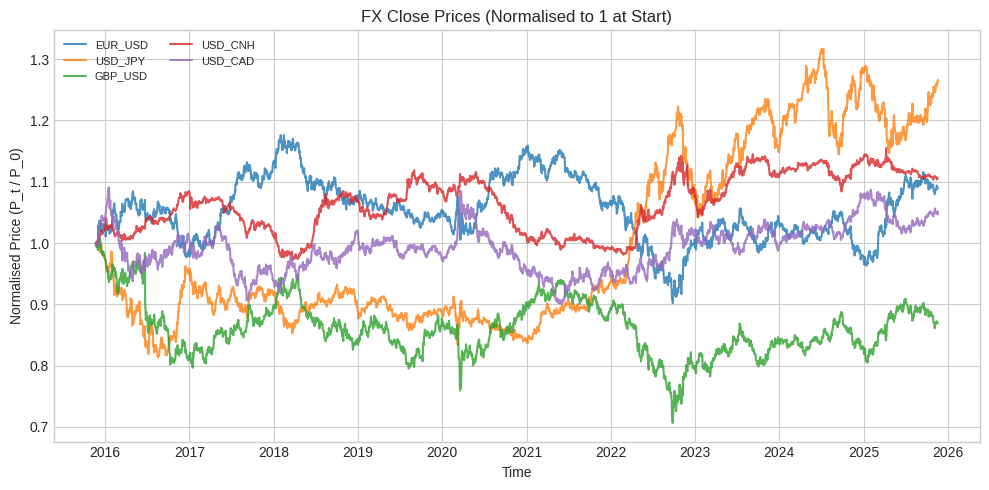

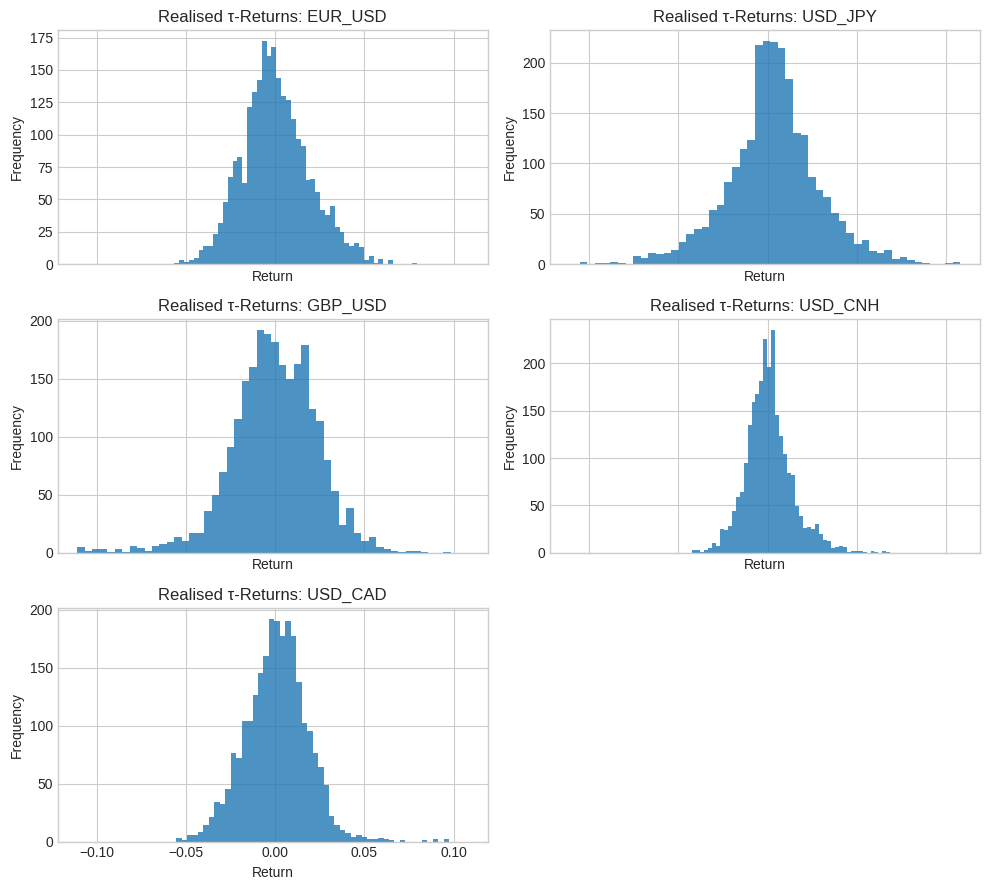

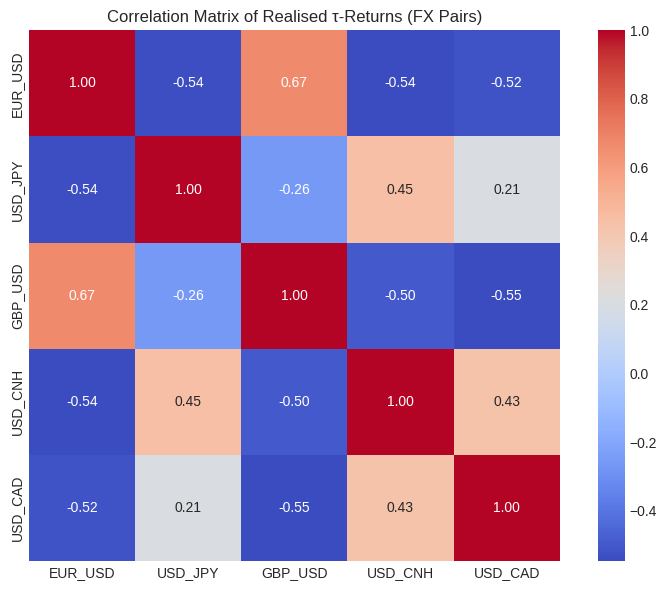

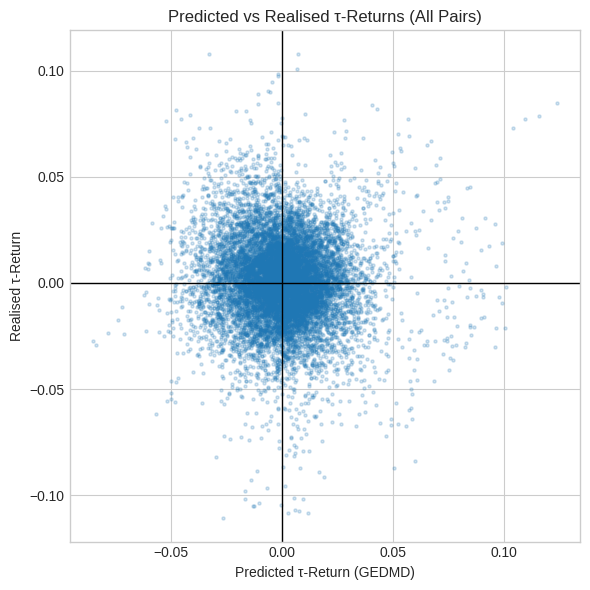

Overall Corr(pred, real): -0.0576


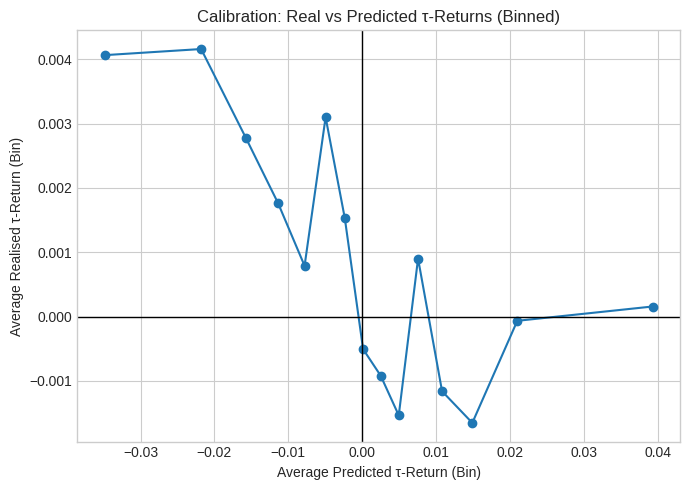


Calibration table (per bin):
 BinCenterPred  MeanPred  MeanReal  Count
     -0.055694 -0.034866  0.004066    830
     -0.022234 -0.021793  0.004162    830
     -0.015819 -0.015722  0.002775    830
     -0.011483 -0.011373  0.001762    830
     -0.007898 -0.007790  0.000789    830
     -0.004948 -0.004942  0.003100    830
     -0.002354 -0.002346  0.001531    830
      0.000106  0.000131 -0.000507    830
      0.002523  0.002513 -0.000920    830
      0.004970  0.004959 -0.001538    830
      0.007668  0.007572  0.000901    830
      0.010889  0.010823 -0.001163    830
      0.015059  0.014917 -0.001655    830
      0.021344  0.021006 -0.000067    830
      0.074459  0.039323  0.000156    829

=== PER-PAIR PREDICTION METRICS (GEDMD VANILLA, FX) ===
   Pair    N      Corr      MSE      MAE
EUR_USD 2490 -0.035064 0.000627 0.019413
USD_JPY 2490 -0.066914 0.001314 0.026071
GBP_USD 2490  0.031450 0.000929 0.024156
USD_CNH 2490 -0.334617 0.000468 0.016136
USD_CAD 2490 -0.033080 0.000604 0.01

In [4]:
# ============================================
# FX ANALYSIS — PRICES + GEDMD DIAGNOSTICS
# Assumes: closes, pred_ret_df, real_ret_df exist
#
# In the thesis:
# - This analysis block is reused for all three scenarios.
# - The only thing that changes between Scenario 1/2/3 is which
#   predictions we feed into pred_ret_df (and which parameters
#   generated them). The plots/tables below are the common lens.
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")  # simple, readable plotting style

# Align shapes just in case:
# - reindex predictions to match realised returns
# - reindex closes to match the same time index and asset set
pred_ret_df = pred_ret_df.reindex_like(real_ret_df)
closes = closes.reindex(real_ret_df.index).reindex(columns=real_ret_df.columns)
pairs = list(closes.columns)

print("closes:", closes.shape)
print("pred_ret_df:", pred_ret_df.shape)
print("real_ret_df:", real_ret_df.shape)

# ------------------------------------------------
# 1) NORMALISED PRICE PLOT (ALL PAIRS)
#    Just to see the joint FX path behaviour on a common scale.
# ------------------------------------------------
norm_closes = closes / closes.iloc[0]  # each series starts at 1

fig, ax = plt.subplots(figsize=(10, 5))
for pair in pairs:
    if norm_closes[pair].notna().any():  # skip assets with no data
        ax.plot(norm_closes.index, norm_closes[pair], label=pair, alpha=0.8)

ax.set_title("FX Close Prices (Normalised to 1 at Start)")
ax.set_xlabel("Time")
ax.set_ylabel("Normalised Price (P_t / P_0)")
ax.legend(loc="upper left", ncol=2, fontsize=8)
ax.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 2) HISTOGRAM OF REALISED τ-HORIZON RETURNS
#    Distributional check: how fat-tailed / skewed the τ-returns
#    are for each pair.
# ------------------------------------------------
rows = int(np.ceil(len(pairs) / 2))   # arrange pair plots in a grid (2 per row)
fig, axes = plt.subplots(rows, 2, figsize=(10, 3 * rows), sharex=True)
axes = axes.flatten()

for i, pair in enumerate(pairs):
    ax = axes[i]
    data = real_ret_df[pair].dropna()
    ax.hist(data, bins=50, alpha=0.8)
    ax.set_title(f"Realised τ-Returns: {pair}")
    ax.set_xlabel("Return")
    ax.set_ylabel("Frequency")

# If we have an odd number of pairs, blank out unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------
# 3) CORRELATION HEATMAP OF REALISED τ-RETURNS
#    Cross-sectional structure: which FX pairs move together at
#    the τ-horizon.
# ------------------------------------------------
real_corr = real_ret_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(real_corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix of Realised τ-Returns (FX Pairs)")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 4) SCATTER: PREDICTED VS REALISED RETURNS (ALL PAIRS)
#    Global sanity check: how well τ-return predictions line up
#    with actual τ-returns across all pairs and dates.
# ------------------------------------------------
pred_flat = pred_ret_df.values.flatten()
real_flat = real_ret_df.values.flatten()

# Only keep entries where both predicted and realised are defined
mask = (~np.isnan(pred_flat)) & (~np.isnan(real_flat))
pred_flat = pred_flat[mask]
real_flat = real_flat[mask]

plt.figure(figsize=(6, 6))
plt.scatter(pred_flat, real_flat, alpha=0.2, s=5)
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Predicted τ-Return (GEDMD)")
plt.ylabel("Realised τ-Return")
plt.title("Predicted vs Realised τ-Returns (All Pairs)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Report overall linear association between predictions and outcomes
if len(pred_flat) > 0:
    corr_all = np.corrcoef(pred_flat, real_flat)[0, 1]
    print(f"Overall Corr(pred, real): {corr_all:.4f}")
else:
    print("No valid points for pred vs real scatter.")

# ------------------------------------------------
# 5) CALIBRATION PLOT (BINNED PREDICTED RETURNS)
#    Idea: if the model is well-calibrated, bins with higher
#    predicted τ-returns should have higher realised τ-returns
#    on average.
# ------------------------------------------------
if len(pred_flat) > 0:
    num_bins = 15
    # Use quantile bins so each bin has roughly the same number of points
    bins = np.quantile(pred_flat, np.linspace(0, 1, num_bins + 1))
    bins = np.unique(bins)  # guard against repeated edges

    if len(bins) > 2:
        bin_idx = np.digitize(pred_flat, bins) - 1

        bin_centers, mean_pred, mean_real, counts = [], [], [], []
        for b in range(len(bins) - 1):
            m = bin_idx == b
            if not m.any():
                continue
            bin_centers.append(0.5 * (bins[b] + bins[b+1]))
            mean_pred.append(pred_flat[m].mean())
            mean_real.append(real_flat[m].mean())
            counts.append(m.sum())

        plt.figure(figsize=(7, 5))
        plt.plot(mean_pred, mean_real, marker="o")
        plt.axhline(0, color="black", linewidth=1)
        plt.axvline(0, color="black", linewidth=1)
        plt.xlabel("Average Predicted τ-Return (Bin)")
        plt.ylabel("Average Realised τ-Return (Bin)")
        plt.title("Calibration: Real vs Predicted τ-Returns (Binned)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # Also print a small table to see calibration numerically
        calib_df = pd.DataFrame({
            "BinCenterPred": bin_centers,
            "MeanPred": mean_pred,
            "MeanReal": mean_real,
            "Count": counts,
        })
        print("\nCalibration table (per bin):")
        print(calib_df.round(6).to_string(index=False))
    else:
        print("Predicted returns too concentrated to form bins.")
else:
    print("No valid points for calibration plot.")

# ------------------------------------------------
# 6) PER-PAIR PREDICTION METRICS (TABLE)
#    Asset-level view: for each FX pair, how strong is the
#    pointwise relationship between predicted and realised τ-returns?
# ------------------------------------------------
rows_metrics = []
for pair in pairs:
    p = pred_ret_df[pair].values
    r = real_ret_df[pair].values
    m = (~np.isnan(p)) & (~np.isnan(r))
    p = p[m]; r = r[m]

    if len(p) < 2:
        # Not enough data points to compute statistics robustly
        rows_metrics.append({
            "Pair": pair, "N": len(p),
            "Corr": np.nan, "MSE": np.nan, "MAE": np.nan
        })
        continue

    corr_pr = np.corrcoef(p, r)[0, 1]      # linear association for this pair
    mse = np.mean((p - r)**2)              # mean squared error
    mae = np.mean(np.abs(p - r))           # mean absolute error

    rows_metrics.append({
        "Pair": pair,
        "N": len(p),
        "Corr": corr_pr,
        "MSE": mse,
        "MAE": mae,
    })

metrics_df = pd.DataFrame(rows_metrics)
print("\n=== PER-PAIR PREDICTION METRICS (GEDMD VANILLA, FX) ===")
print(metrics_df.round(6).to_string(index=False))


In [31]:
import itertools
import time
import numpy as np
import pandas as pd
from scipy.stats import norm

# =========================================================
# GLOBAL DEFINITIONS FOR GEDMD CORES AND HELPERS
# These are extracted and made global for reuse in walk-forward.
# =========================================================

class GEDMD_Core_GS:
    def __init__(self, k=5, confidence=0.99, c_threshold=0.05, lambda_scale=0.1):
        self.k = k
        self.confidence = confidence
        self.c_threshold = c_threshold
        self.lambda_scale = lambda_scale

    def get_significant_neighbors(self, returns, target_idx):
        n = len(returns)
        if n < 4:
            return [target_idx]

        corrs = returns.corr().iloc[target_idx]
        corrs_clip = np.clip(corrs.values, -0.9999, 0.9999)
        z = 0.5 * np.log((1 + corrs_clip) / (1 - corrs_clip))
        se = 1.0 / np.sqrt(n - 3)

        z_crit = norm.ppf((1 + self.confidence) / 2)
        z_lower = z - z_crit * se
        z_upper = z + z_crit * se

        r_lower_signed = (np.exp(2*z_lower)-1)/(np.exp(2*z_lower)+1)
        r_upper_signed = (np.exp(2*z_upper)-1)/(np.exp(2*z_upper)+1)

        lower_abs = np.zeros_like(r_lower_signed)
        pos_mask = (r_lower_signed>0)&(r_upper_signed>0)
        lower_abs[pos_mask] = r_lower_signed[pos_mask]
        neg_mask = (r_lower_signed<0)&(r_upper_signed<0)
        lower_abs[neg_mask] = -r_upper_signed[neg_mask]

        valid_mask = lower_abs > self.c_threshold
        valid_names = corrs.index[valid_mask].tolist()

        self_name = returns.columns[target_idx]
        if self_name not in valid_names:
            valid_names.append(self_name)

        if len(valid_names)==0:
            valid_names=[self_name]

        best = corrs.abs().loc[valid_names].nlargest(self.k).index
        return [returns.columns.get_loc(c) for c in best]

    def solve_tikhonov(self, X1, X2):
        U, S, Vt = np.linalg.svd(X1, full_matrices=False)
        if len(S)==0 or S[-1]<1e-12:
            return np.zeros((X2.shape[0], X1.shape[1]))

        sigma1 = S[0]
        lam = self.lambda_scale * (sigma1**2)
        if lam <= 0: lam=1e-8

        dampened = S / (S**2 + lam)
        return X2 @ Vt.T @ np.diag(dampened) @ U.T

def portfolio_stats(period_rets, tau):
    arr = np.array(period_rets, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr)==0:
        return 0.0,0.0,0.0

    mu = arr.mean()
    sig = arr.std(ddof=1) if len(arr)>1 else 0.0

    per_year = 252.0 / tau
    ann_ret = mu * per_year
    ann_vol = sig * np.sqrt(per_year) if sig>0 else 0
    sharpe = ann_ret/ann_vol if ann_vol>0 else 0
    return ann_ret, ann_vol, sharpe

# =========================================================
# GRID SEARCH FOR FX GEDMD (SCALED λ VERSION)
# =========================================================

TAU_GRID          = [20]
L_GRID            = [10, 20, 30]
M_GRID            = [80, 120]
K_GRID            = [3, 5]
C_THRESHOLD_GRID  = [0.01, 0.05, 0.10]
LAMBDA_SCALE_GRID = [0.01, 0.1, 1.0]

def run_single_config(tau, L_val, M_val, k_val, c_thr, lambda_scale):
    T_loc, N_loc = closes.shape

    pred_ret = np.full((T_loc, N_loc), np.nan)
    real_ret = np.full((T_loc, N_loc), np.nan)

    def run_window(window_raw):
        current_prices = window_raw.iloc[-1]
        norm_window = window_raw / current_prices
        returns = norm_window.pct_change().dropna()

        data_values = norm_window.values
        M_win, N_win = data_values.shape

        model = GEDMD_Core_GS(
            k=k_val,
            confidence=CONFIDENCE,
            c_threshold=c_thr,
            lambda_scale=lambda_scale
        )

        preds = []
        start_t = L_val - 1
        end_t = M_win - 1 - tau
        if start_t > end_t:
            return np.full(N_win, np.nan)

        for i in range(N_win):
            neighbors = model.get_significant_neighbors(returns, i)
            neighbor_data = data_values[:, neighbors]
            target_data   = data_values[:, [i]]

            X1_cols, X2_cols = [], []
            for t in range(start_t, end_t+1):
                x1 = create_hankel_snapshot(neighbor_data, t, L_val)
                x2 = create_hankel_snapshot(target_data,   t+tau, L_val)
                X1_cols.append(x1)
                X2_cols.append(x2)

            X1 = np.hstack(X1_cols)
            X2 = np.hstack(X2_cols)

            B = model.solve_tikhonov(X1, X2)
            x_cur = create_hankel_snapshot(neighbor_data, M_win-1, L_val)
            pred_norm = (B @ x_cur)[-1].item()
            preds.append(pred_norm * current_prices.iloc[i])

        return np.array(preds)

    for t_idx in range(M_val-1, T_loc-tau):
        window_raw = closes.iloc[t_idx-M_val+1 : t_idx+1]
        pred_prices = run_window(window_raw)

        current_prices = closes.iloc[t_idx].values
        future_prices  = closes.iloc[t_idx+tau].values

        pred_ret[t_idx] = (pred_prices/current_prices) - 1
        real_ret[t_idx] = (future_prices/current_prices) - 1

    pred_df = pd.DataFrame(pred_ret, index=closes.index, columns=pairs)
    real_df = pd.DataFrame(real_ret, index=closes.index, columns=pairs)

    rebal_idx = list(range(M_val-1, T_loc-tau, tau))

    best_sharpe = -9e9
    best_threshold = None
    best_bench_sharpe = None

    for c in THRESHOLDS:
        ged_rets = []
        bench_rets = []

        for t_idx in rebal_idx:
            pred_row = pred_df.iloc[t_idx]
            real_row = real_df.iloc[t_idx]
            mask = (~pred_row.isna()) & (~real_row.isna())
            if not mask.any(): continue

            sel = (pred_row >= c) & mask
            r_ged = real_row[sel].mean() if sel.any() else real_row[mask].mean()
            r_bench = real_row[mask].mean()

            ged_rets.append(r_ged)
            bench_rets.append(r_bench)

        _,_,sh = portfolio_stats(ged_rets, tau)
        _,_,sh_b = portfolio_stats(bench_rets, tau)

        if sh > best_sharpe:
            best_sharpe = sh
            best_threshold = c
            best_bench_sharpe = sh_b

    return dict(
        TAU=tau, L=L_val, M=M_val, k=k_val, c_thr=c_thr,
        lambda_scale=lambda_scale,
        best_GEDMD_Sharpe=best_sharpe,
        best_threshold=best_threshold,
        bench_Sharpe_at_best=best_bench_sharpe
    )


configs = list(itertools.product(
    TAU_GRID, L_GRID, M_GRID, K_GRID,
    C_THRESHOLD_GRID, LAMBDA_SCALE_GRID
))

results=[]
start=time.time()

for i,(tau,L_val,M_val,k_val,c_thr,lam_s) in enumerate(configs,1):
    print(f"[{i}/{len(configs)}] τ={tau}, L={L_val}, M={M_val}, k={k_val}, c={c_thr}, λ_scale={lam_s}")
    results.append(run_single_config(tau,L_val,M_val,k_val,c_thr,lam_s))

print(f"\nGrid search finished in { (time.time()-start)/60:.1f} minutes.")

results_df=pd.DataFrame(results).sort_values("best_GEDMD_Sharpe",ascending=False)
print("\n=== TOP RESULTS ===")
print(results_df.head(10).to_string(index=False))

[1/108] τ=20, L=10, M=80, k=3, c=0.01, λ_scale=0.01
[2/108] τ=20, L=10, M=80, k=3, c=0.01, λ_scale=0.1
[3/108] τ=20, L=10, M=80, k=3, c=0.01, λ_scale=1.0
[4/108] τ=20, L=10, M=80, k=3, c=0.05, λ_scale=0.01
[5/108] τ=20, L=10, M=80, k=3, c=0.05, λ_scale=0.1
[6/108] τ=20, L=10, M=80, k=3, c=0.05, λ_scale=1.0
[7/108] τ=20, L=10, M=80, k=3, c=0.1, λ_scale=0.01
[8/108] τ=20, L=10, M=80, k=3, c=0.1, λ_scale=0.1
[9/108] τ=20, L=10, M=80, k=3, c=0.1, λ_scale=1.0
[10/108] τ=20, L=10, M=80, k=5, c=0.01, λ_scale=0.01
[11/108] τ=20, L=10, M=80, k=5, c=0.01, λ_scale=0.1
[12/108] τ=20, L=10, M=80, k=5, c=0.01, λ_scale=1.0
[13/108] τ=20, L=10, M=80, k=5, c=0.05, λ_scale=0.01
[14/108] τ=20, L=10, M=80, k=5, c=0.05, λ_scale=0.1
[15/108] τ=20, L=10, M=80, k=5, c=0.05, λ_scale=1.0
[16/108] τ=20, L=10, M=80, k=5, c=0.1, λ_scale=0.01
[17/108] τ=20, L=10, M=80, k=5, c=0.1, λ_scale=0.1
[18/108] τ=20, L=10, M=80, k=5, c=0.1, λ_scale=1.0
[19/108] τ=20, L=10, M=120, k=3, c=0.01, λ_scale=0.01
[20/108] τ=20, L=10

Loaded closes: T=2629, N=5, pairs=['EUR_USD', 'USD_JPY', 'GBP_USD', 'USD_CNH', 'USD_CAD']
Finished GEDMD forecasting for Scenario 2 (FX-optimised, constant λ).

=== SCENARIO 2: SIGNAL QUALITY (PRECISION & RECALL VS THRESHOLD) ===
 Threshold_%  TP   FP   FN    TN  Precision_%  Recall_%
           1 873 2012 2813  7447    30.259965 23.684211
           2 243 1068 1626 10208    18.535469 13.001605
           3  74  600  784 11687    10.979228  8.624709
           4  32  363  373 12377     8.101266  7.901235
           5  21  230  158 12736     8.366534 11.731844
           6  12  175   72 12886     6.417112 14.285714
           7   6  125   30 12984     4.580153 16.666667
           8   1   97   16 13031     1.020408  5.882353
           9   0   83    7 13055     0.000000  0.000000
          10   0   73    3 13069     0.000000  0.000000

=== SCENARIO 2: TRADING PERFORMANCE (YIP-STYLE, LONG-ONLY, τ=20) ===
 Threshold_%  GEDMD_AnnRet_%  GEDMD_AnnVol_%  GEDMD_Sharpe  Benchmark_AnnRet_%  Benc

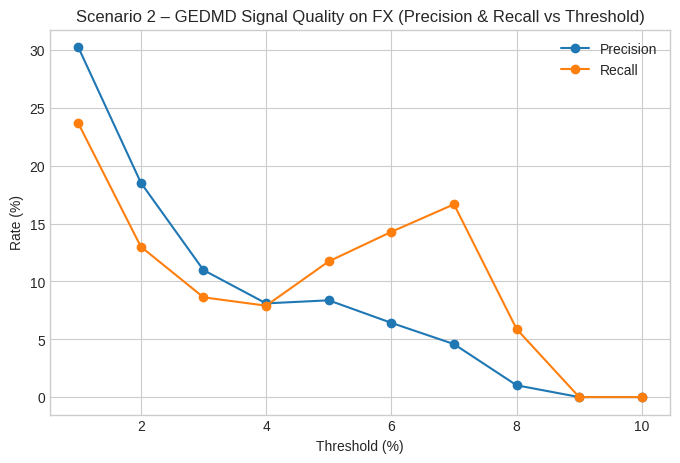

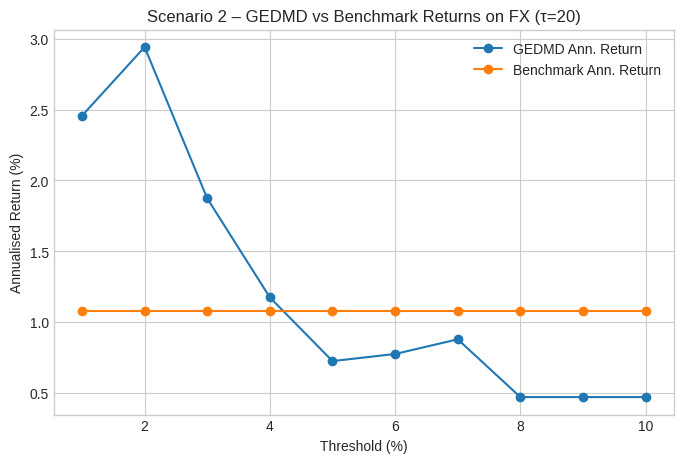

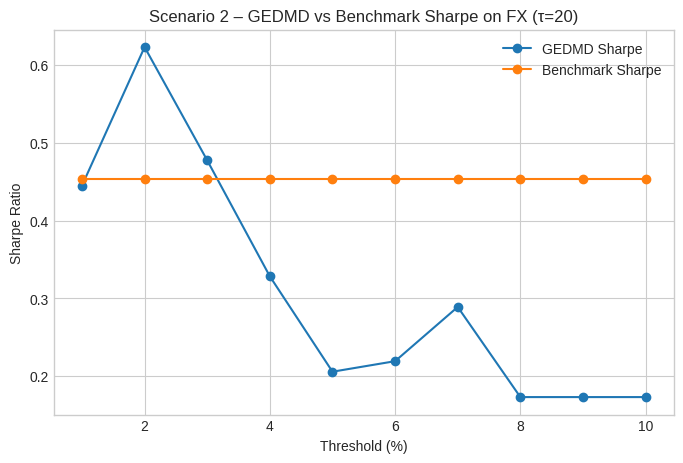

In [33]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# SCENARIO 2: FX-OPTIMISED GEDMD WITH CONSTANT TIKHONOV λ
#
# - Same overall GEDMD structure as the baseline.
# - Hyperparameters (M, L, k, c_threshold, λ) have been chosen
#   from a prior grid search on the FX panel and are now
#   hard-coded here.
# - λ is kept constant at LAMBDA_REG = 0.01 in this scenario.
#
# Outputs:
#   - pred_ret_df, real_ret_df: τ-horizon predicted & realised returns
#   - pr_df: precision/recall vs threshold
#   - tr_df: trading performance vs threshold (GEDMD vs benchmark)
#   - Figures: signal quality + Sharpe/return profiles
# ============================================================

# ============================================================
# 0. GLOBAL PARAMETERS (FX-OPTIMISED FROM GRID SEARCH)
# ============================================================
TAU = 20                # Forecast horizon (≈ 1 month of trading days)
L = 30                  # Hankel embedding length
M = 80                  # Window length for each GEDMD fit
K_NEIGHBOURS = 3        # Max neighbours per asset in the graph

CONFIDENCE = 0.99       # 99% CI for correlations
C_THRESHOLD = 0.05      # lower bound on |rho| for significance
LAMBDA_REG = 0.01       # Tikhonov parameter (constant λ, chosen from FX grid search)

THRESHOLDS = np.arange(0.01, 0.11, 0.01)  # 1% to 10% thresholds for up-move events


# ============================================================
# 1. LOAD FX DATA (MERGED FOREX PANEL)
# ============================================================
# Expected CSV format:
#   - First column: timestamp
#   - Remaining columns: MultiIndex (pair, field), where field includes 'close'
df_raw = pd.read_csv('merged_forex_data.csv', header=[0, 1])

# Handle a possible extra 'timestamp' header row sneaking in
if str(df_raw.iloc[0, 0]).lower() == 'timestamp':
    df_raw = df_raw.iloc[1:]

# Set index to timestamp and drop the original timestamp column
df_raw.index = pd.to_datetime(df_raw.iloc[:, 0], utc=True)
df_raw = df_raw.iloc[:, 1:]

# Use only close prices for GEDMD
closes = df_raw.xs('close', level=1, axis=1).astype(float).ffill().dropna()
pairs = closes.columns
T, N = closes.shape
print(f"Loaded closes: T={T}, N={N}, pairs={list(pairs)}")


# ============================================================
# 2. GEDMD CORE (CONSTANT-λ VERSION)
# ============================================================

class GEDMD_Core:
    """
    Graph Embedded DMD with Tikhonov regularization.
    Implements the per-asset B(i) formulation in Yip et al. (2023), Sec. 3.2–3.3,
    but with a constant Tikhonov parameter λ (no adaptive condition-number tuning).
    """
    def __init__(self, k=5, confidence=0.99, c_threshold=0.05, lambda_reg=0.1):
        self.k = k
        self.confidence = confidence
        self.c_threshold = c_threshold
        self.lambda_reg = lambda_reg

    def get_significant_neighbors(self, returns, target_idx):
        """
        Construct the directed graph row for asset i (Sec. 3.1 style):
        - Compute correlations of simple returns across assets.
        - Apply Fisher z-transform and build a (1 - α) confidence interval.
        - Take the lower bound for |rho|.
        - Keep links with lower bound > c_threshold.
        - Among those, keep the top k by |rho|.
        Always include self.
        """
        n = len(returns)
        if n < 4:
            return [target_idx]

        corrs = returns.corr().iloc[target_idx]  # Series indexed by asset name

        # Fisher z-transform with clipping for numerical stability
        corrs_clip = np.clip(corrs.values, -0.9999, 0.9999)
        z = 0.5 * np.log((1.0 + corrs_clip) / (1.0 - corrs_clip))
        se = 1.0 / np.sqrt(n - 3)

        z_crit = stats.norm.ppf((1.0 + self.confidence) / 2.0)
        z_lower = z - z_crit * se
        z_upper = z + z_crit * se

        # Inverse Fisher transform back to correlation space
        r_lower_signed = (np.exp(2.0 * z_lower) - 1.0) / (np.exp(2.0 * z_lower) + 1.0)
        r_upper_signed = (np.exp(2.0 * z_upper) - 1.0) / (np.exp(2.0 * z_upper) + 1.0)

        lower_abs = np.zeros_like(r_lower_signed)

        # CI entirely positive → lower bound = lower end
        pos_mask = (r_lower_signed > 0) & (r_upper_signed > 0)
        lower_abs[pos_mask] = r_lower_signed[pos_mask]

        # CI entirely negative → lower bound = -upper
        neg_mask = (r_lower_signed < 0) & (r_upper_signed < 0)
        lower_abs[neg_mask] = -r_upper_signed[neg_mask]

        # CI crossing zero → lower_abs stays 0

        valid_mask = lower_abs > self.c_threshold
        valid_names = corrs.index[valid_mask].tolist()

        # Always include self as a neighbour
        self_name = returns.columns[target_idx]
        if self_name not in valid_names:
            valid_names.append(self_name)

        if len(valid_names) == 0:
            valid_names = [self_name]

        corrs_abs = corrs.abs()
        best = corrs_abs.loc[valid_names].nlargest(self.k).index

        # Return neighbour indices corresponding to the chosen asset names
        return [returns.columns.get_loc(c) for c in best]

    def solve_tikhonov(self, X1, X2):
        """
        Solve the regularised least-squares problem

            min_B ||B X1 - X2||^2 + λ ||B||^2,

        via SVD with the closed-form expression used in regularised DMD.
        Here λ is a *constant* Tikhonov parameter (lambda_reg).
        """
        U, S, Vt = np.linalg.svd(X1, full_matrices=False)

        # Degenerate case: ill-posed or rank-deficient X1
        if len(S) == 0 or S[-1] < 1e-12:
            return np.zeros((X2.shape[0], X1.shape[1]))

        lam = float(self.lambda_reg)
        if lam <= 0:
            lam = 1e-8  # small floor just to avoid divide-by-zero issues

        dampened = S / (S**2 + lam)
        return X2 @ Vt.T @ np.diag(dampened) @ U.T


def create_hankel_snapshot(data_matrix, end_idx, L):
    """
    Build an L-step time-delay embedding stacked across all series in data_matrix.

    Parameters
    ----------
    data_matrix : array of shape (M, K)
        M time points by K assets.
    end_idx : int
        Index of the last time point included in the embedding.
    L : int
        Embedding length.

    Returns
    -------
    column vector of length K * L
    """
    window = data_matrix[end_idx - L + 1 : end_idx + 1, :]
    return window.T.flatten().reshape(-1, 1)


def fit_gedmd_local_forecast(window_raw, tau=TAU, L=L,
                             k=K_NEIGHBOURS,
                             confidence=CONFIDENCE,
                             c_threshold=C_THRESHOLD,
                             lambda_reg=LAMBDA_REG):
    """
    Given a window of raw prices (M x N), fit GEDMD with the chosen
    hyperparameters and forecast normalised prices at t_M + tau
    for all N assets.

    Returns
    -------
    preds : array of length N
        Predicted prices at t_M + tau for each asset, rescaled back
        into price space.
    mean_recon_error : float
        Average relative reconstruction error over the calibration slices,
        used as a diagnostic for operator fit quality.
    """
    current_prices = window_raw.iloc[-1]
    norm_window = window_raw / current_prices   # normalise by last price in window

    returns = norm_window.pct_change().dropna()
    data_values = norm_window.values   # shape (M, N)
    M_loc, N_loc = data_values.shape

    model = GEDMD_Core(
        k=k,
        confidence=confidence,
        c_threshold=c_threshold,
        lambda_reg=lambda_reg
    )

    preds = []
    errors = []

    start_t = L - 1
    end_t = M_loc - 1 - tau

    # If there is no room to shift by τ inside the window, bail out
    if start_t > end_t:
        return np.full(N_loc, np.nan), np.inf

    for i in range(N_loc):
        neighbors_idx = model.get_significant_neighbors(returns, i)

        neighbor_data = data_values[:, neighbors_idx]  # M x Ni
        target_data = data_values[:, [i]]              # M x 1

        X1_cols = []
        X2_cols = []

        # Build Hankel snapshots over the training slices
        for t in range(start_t, end_t + 1):
            x1 = create_hankel_snapshot(neighbor_data, t, L)
            x2 = create_hankel_snapshot(target_data, t + tau, L)
            X1_cols.append(x1)
            X2_cols.append(x2)

        X1 = np.hstack(X1_cols)
        X2 = np.hstack(X2_cols)

        # Fit local operator B(i) and compute reconstruction error
        B = model.solve_tikhonov(X1, X2)

        recon = B @ X1
        res = np.linalg.norm(X2 - recon) / (np.linalg.norm(X2) + 1e-9)
        errors.append(res)

        # Forecast τ steps ahead by pushing the current embedded state
        x_current = create_hankel_snapshot(neighbor_data, M_loc - 1, L)
        pred_traj = B @ x_current
        pred_norm_price = pred_traj[-1].item()

        # Rescale from normalised back to price space
        preds.append(pred_norm_price * current_prices.iloc[i])

    return np.array(preds), float(np.mean(errors))


# ============================================================
# 3. RUN GEDMD OVER FULL FX PANEL: PREDICTED & REALISED RETURNS
# ============================================================
T, N = closes.shape
pred_ret = np.full((T, N), np.nan)
real_ret = np.full((T, N), np.nan)

recon_errors = []  # store reconstruction errors per window

for t_idx in range(M - 1, T - TAU):
    window_raw = closes.iloc[t_idx - M + 1 : t_idx + 1]
    pred_prices, err = fit_gedmd_local_forecast(window_raw)

    recon_errors.append(err)

    current_prices = closes.iloc[t_idx].values
    future_prices = closes.iloc[t_idx + TAU].values

    # Predicted and realised τ-horizon returns
    pred_ret[t_idx, :] = (pred_prices / current_prices) - 1.0
    real_ret[t_idx, :] = (future_prices / current_prices) - 1.0

pred_ret_df = pd.DataFrame(pred_ret, index=closes.index, columns=pairs)
real_ret_df = pd.DataFrame(real_ret, index=closes.index, columns=pairs)
print("Finished GEDMD forecasting for Scenario 2 (FX-optimised, constant λ).")


# ============================================================
# 4. SIGNAL QUALITY: PRECISION & RECALL VS THRESHOLD
# ============================================================
def compute_precision_recall(pred_ret_df, real_ret_df, c):
    """
    Compute confusion-matrix counts and derived precision/recall
    for the event { τ-horizon return ≥ c }.
    """
    mask = (~pred_ret_df.isna()) & (~real_ret_df.isna())
    y_pred_up = (pred_ret_df >= c) & mask
    y_true_up = (real_ret_df >= c) & mask

    TP = (y_pred_up & y_true_up).sum().sum()
    FP = (y_pred_up & ~y_true_up).sum().sum()
    FN = (~y_pred_up & y_true_up).sum().sum()
    TN = (~y_pred_up & ~y_true_up).sum().sum()

    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan

    return TP, FP, FN, TN, precision, recall


rows_pr = []
for c in THRESHOLDS:
    TP, FP, FN, TN, precision, recall = compute_precision_recall(pred_ret_df, real_ret_df, c)
    rows_pr.append({
        "Threshold_%": int(round(c * 100)),
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN,
        "Precision_%": 100 * precision if precision is not np.nan else np.nan,
        "Recall_%": 100 * recall if recall is not np.nan else np.nan,
    })

pr_df = pd.DataFrame(rows_pr)
print("\n=== SCENARIO 2: SIGNAL QUALITY (PRECISION & RECALL VS THRESHOLD) ===")
print(pr_df.to_string(index=False))


# ============================================================
# 5. TRADING PERFORMANCE (YIP-STYLE PORTFOLIO, NO RISK SHELL)
#    - Long-only, equal-weight of predicted-UP assets
#    - Rebalance every τ days
#    - Benchmark: equal-weight all assets every τ days
# ============================================================
def portfolio_stats_from_period_returns(period_rets, tau_days=TAU, label="GEDMD"):
    """
    Convert a sequence of τ-horizon period returns into annualised
    return, annualised volatility and Sharpe ratio.
    """
    period_rets = np.array(period_rets, dtype=float)
    period_rets = period_rets[~np.isnan(period_rets)]
    if len(period_rets) == 0:
        return dict(Label=label, AvgRet=0, StdRet=0, AnnRet=0, AnnVol=0, Sharpe=0, NumPeriods=0)

    mu = np.mean(period_rets)
    sigma = np.std(period_rets, ddof=1) if len(period_rets) > 1 else 0.0

    periods_per_year = 252.0 / tau_days
    ann_ret = mu * periods_per_year
    ann_vol = sigma * np.sqrt(periods_per_year) if sigma > 0 else 0.0
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0.0

    return dict(
        Label=label,
        AvgRet=mu,
        StdRet=sigma,
        AnnRet=ann_ret,
        AnnVol=ann_vol,
        Sharpe=sharpe,
        NumPeriods=len(period_rets),
    )


rows_tr = []
rebal_indices = list(range(M - 1, T - TAU, TAU))

for c in THRESHOLDS:
    gedmd_rets = []
    bench_rets = []

    for t_idx in rebal_indices:
        # Only use times where both predicted and realised returns exist
        pred_row = pred_ret_df.iloc[t_idx]
        real_row = real_ret_df.iloc[t_idx]

        mask = (~pred_row.isna()) & (~real_row.isna())
        if not mask.any():
            continue

        # GEDMD portfolio: assets with predicted return >= c
        sel_mask = (pred_row >= c) & mask
        if sel_mask.any():
            r_ged = real_row[sel_mask].mean()
        else:
            # Fallback: if GEDMD selects no assets, use benchmark at this step
            r_ged = real_row[mask].mean()

        # Benchmark: equal-weight all assets (mask)
        r_bench = real_row[mask].mean()

        gedmd_rets.append(r_ged)
        bench_rets.append(r_bench)

    stats_ged = portfolio_stats_from_period_returns(
        gedmd_rets, tau_days=TAU, label=f"GEDMD c={int(c*100)}%"
    )
    stats_ben = portfolio_stats_from_period_returns(
        bench_rets, tau_days=TAU, label=f"Benchmark c={int(c*100)}%"
    )

    rows_tr.append({
        "Threshold_%": int(round(c * 100)),
        "GEDMD_AnnRet_%": 100 * stats_ged["AnnRet"],
        "GEDMD_AnnVol_%": 100 * stats_ged["AnnVol"],
        "GEDMD_Sharpe": stats_ged["Sharpe"],
        "Benchmark_AnnRet_%": 100 * stats_ben["AnnRet"],
        "Benchmark_AnnVol_%": 100 * stats_ben["AnnVol"],
        "Benchmark_Sharpe": stats_ben["Sharpe"],
        "NumPeriods": stats_ged["NumPeriods"],
    })

tr_df_s2 = pd.DataFrame(rows_tr)
print("\n=== SCENARIO 2: TRADING PERFORMANCE (YIP-STYLE, LONG-ONLY, τ=20) ===")
print(tr_df_s2.to_string(index=False))


# ============================================================
# 6. VISUALISATIONS (PRECISION/RECALL, RETURNS, SHARPE VS THRESHOLD)
# ============================================================

# Precision & recall vs threshold
plt.figure(figsize=(8, 5))
plt.plot(pr_df["Threshold_%"][:len(tr_df_s2)], pr_df["Precision_%"][:len(tr_df_s2)], marker='o', label="Precision")
plt.plot(pr_df["Threshold_%"][:len(tr_df_s2)], pr_df["Recall_%"][:len(tr_df_s2)], marker='o', label="Recall")
plt.xlabel("Threshold (%)")
plt.ylabel("Rate (%)")
plt.title("Scenario 2 – GEDMD Signal Quality on FX (Precision & Recall vs Threshold)")
plt.grid(True)
plt.legend()
plt.show()

# Annualised return vs threshold (GEDMD vs Benchmark)
plt.figure(figsize=(8, 5))
plt.plot(tr_df_s2["Threshold_%"][:len(tr_df_s2)], tr_df_s2["GEDMD_AnnRet_%"][:len(tr_df_s2)], marker='o', label="GEDMD Ann. Return")
plt.plot(tr_df_s2["Threshold_%"][:len(tr_df_s2)], tr_df_s2["Benchmark_AnnRet_%"][:len(tr_df_s2)], marker='o', label="Benchmark Ann. Return")
plt.xlabel("Threshold (%)")
plt.ylabel("Annualised Return (%)")
plt.title("Scenario 2 – GEDMD vs Benchmark Returns on FX (τ=20)")
plt.grid(True)
plt.legend()
plt.show()

# Sharpe vs threshold (GEDMD vs Benchmark)
plt.figure(figsize=(8, 5))
plt.plot(tr_df_s2["Threshold_%"][:len(tr_df_s2)], tr_df_s2["GEDMD_Sharpe"][:len(tr_df_s2)], marker='o', label="GEDMD Sharpe")
plt.plot(tr_df_s2["Threshold_%"][:len(tr_df_s2)], tr_df_s2["Benchmark_Sharpe"][:len(tr_df_s2)], marker='o', label="Benchmark Sharpe")
plt.xlabel("Threshold (%)")
plt.ylabel("Sharpe Ratio")
plt.title("Scenario 2 – GEDMD vs Benchmark Sharpe on FX (τ=20)")
plt.grid(True)
plt.legend()
plt.show()

Scenario 3: running scaled-λ GEDMD with grid-searched optimal parameters:
  TAU          = 20
  L            = 30
  M            = 80
  k            = 3
  c_threshold  = 0.05
  lambda_scale = 0.01

--- Scenario 3: Optimal Configuration Performance ---
Best GEDMD Sharpe: 1.0346
Best Threshold (c): 0.01
Benchmark Sharpe at best c: 0.4528

=== Scenario 3: Signal Quality (Precision & Recall vs Threshold) ===


,Threshold_%,TP,FP,FN,TN,Precision_%,Recall_%
0,1,465,710,3221,8749,39.574468,12.615301
1,2,152,282,1717,10994,35.023041,8.132691
2,3,46,111,812,12176,29.299363,5.361305
3,4,24,56,381,12684,30.000000,5.925926
4,5,14,31,165,12935,31.111111,7.821229
5,6,9,24,75,13037,27.272727,10.714286
6,7,4,13,32,13096,23.529412,11.111111
7,8,1,3,16,13125,25.000000,5.882353
8,9,0,0,7,13138,NaN,0.000000
9,10,0,0,3,13142,NaN,0.000000



=== Scenario 3: Trading Performance vs Threshold (GEDMD vs Benchmark) ===


,Threshold_%,GEDMD_AnnRet_%,GEDMD_AnnVol_%,GEDMD_Sharpe,Benchmark_AnnRet_%,Benchmark_AnnVol_%,Benchmark_Sharpe,NumPeriods
0,1,4.854128,4.691844,1.034589,1.078236,2.381385,0.452777,127
1,2,3.502252,4.313982,0.811837,1.078236,2.381385,0.452777,127
2,3,2.590128,3.967685,0.652806,1.078236,2.381385,0.452777,127
3,4,1.775044,3.377389,0.525567,1.078236,2.381385,0.452777,127
4,5,1.676012,2.833622,0.591474,1.078236,2.381385,0.452777,127
5,6,1.676012,2.833622,0.591474,1.078236,2.381385,0.452777,127
6,7,1.676012,2.833622,0.591474,1.078236,2.381385,0.452777,127
7,8,1.078236,2.381385,0.452777,1.078236,2.381385,0.452777,127
8,9,1.078236,2.381385,0.452777,1.078236,2.381385,0.452777,127
9,10,1.078236,2.381385,0.452777,1.078236,2.381385,0.452777,127


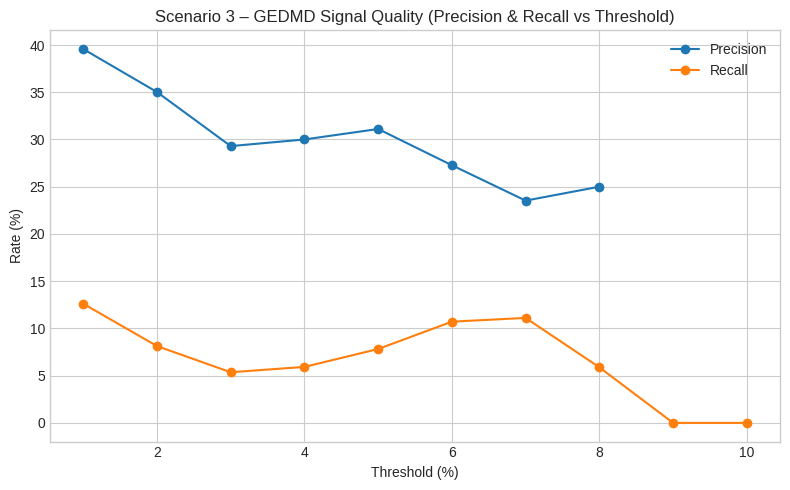

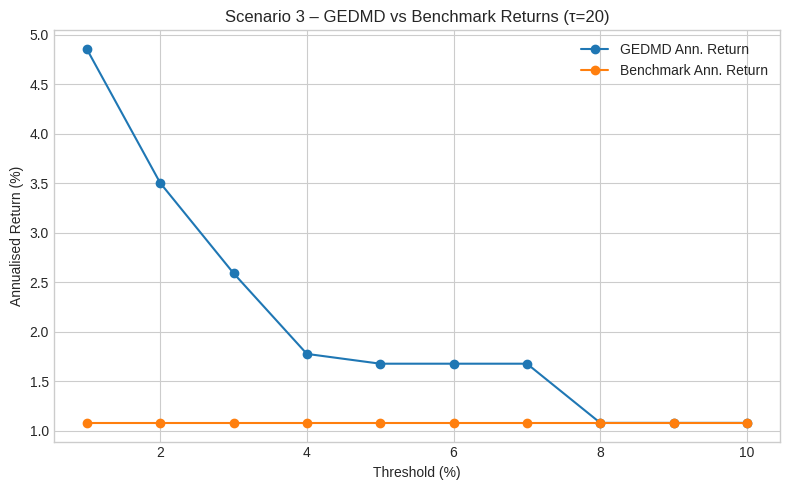

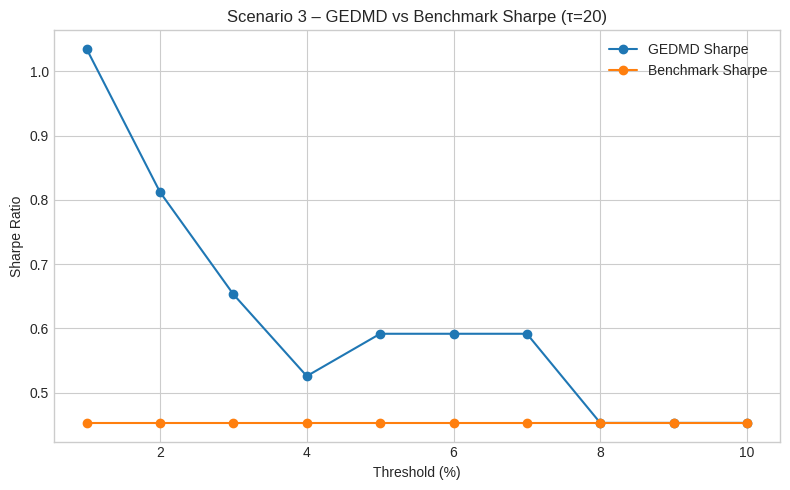

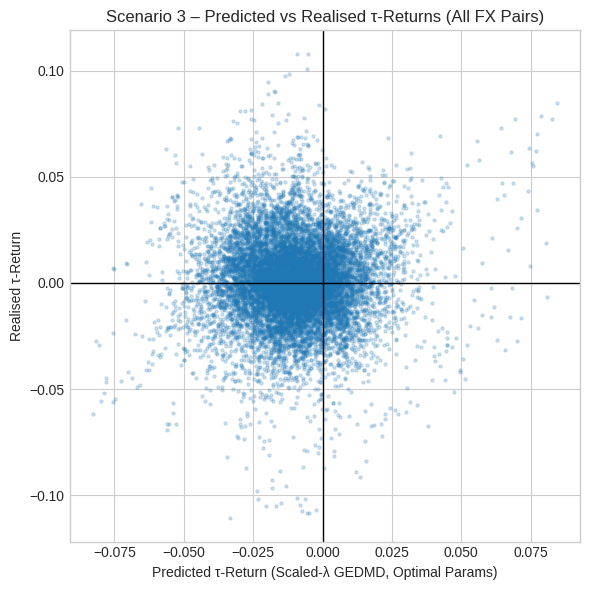

Scenario 3 – Overall Corr(pred, real): 0.0262

--- Scenario 3: Calibration (Binned Predicted Returns) ---


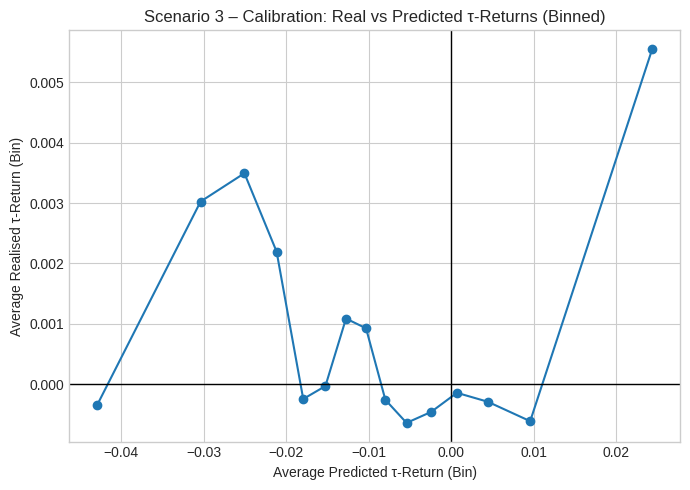


Scenario 3 – Calibration table (per bin):
 BinCenterPred  MeanPred  MeanReal  Count
     -0.058296 -0.042894 -0.000351    844
     -0.030596 -0.030360  0.003024    843
     -0.025194 -0.025053  0.003494    843
     -0.021185 -0.021154  0.002195    844
     -0.017979 -0.017931 -0.000248    843
     -0.015280 -0.015245 -0.000033    843
     -0.012740 -0.012752  0.001085    843
     -0.010324 -0.010324  0.000924    844
     -0.007960 -0.007986 -0.000261    843
     -0.005408 -0.005417 -0.000644    843
     -0.002516 -0.002451 -0.000462    843
      0.000754  0.000679 -0.000145    844
      0.004519  0.004416 -0.000293    843
      0.010046  0.009549 -0.000615    843
      0.048983  0.024328  0.005553    843


In [34]:
# ============================================================
# SCENARIO 3: SCALED-λ GEDMD ON FX (GRID-SEARCHED OPTIMAL PARAMS)
#
# This cell:
#   • Uses the scaled-λ GEDMD core: λ = lambda_scale * σ₁² (per window).
#   • Pulls the best configuration from `results_df` (output of the grid search).
#   • Re-runs GEDMD with that single configuration over the FX panel.
#   • Computes:
#       - τ-horizon predicted and realised returns,
#       - precision/recall vs threshold,
#       - trading performance vs benchmark,
#       - predicted vs realised scatter,
#       - binned calibration curve + table.
#
# Assumes these already exist from previous cells:
#   - closes, pairs
#   - CONFIDENCE, THRESHOLDS
#   - results_df           (from grid search)
#   - create_hankel_snapshot (Hankel embedding helper)
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Scaled-λ GEDMD core (same as used inside the grid search)
# ------------------------------------------------------------
class GEDMD_Core_GS:
    def __init__(self, k=5, confidence=0.99, c_threshold=0.05, lambda_scale=0.1):
        self.k = k                           # max neighbours per asset in the graph
        self.confidence = confidence         # Fisher-z CI level for correlations
        self.c_threshold = c_threshold       # minimum lower bound on |ρ|
        self.lambda_scale = lambda_scale     # λ = lambda_scale * σ₁²

    def get_significant_neighbors(self, returns, target_idx):
        """
        Build the neighbour set for asset i:
          - compute correlations on simple returns,
          - use Fisher-z transform for CI,
          - keep neighbours whose |ρ| CI lower bound exceeds c_threshold,
          - always include the asset itself,
          - among valid neighbours, keep top-k by |ρ|.
        """
        n = len(returns)
        if n < 4:
            # Not enough data → fallback to self only
            return [target_idx]

        corrs = returns.corr().iloc[target_idx]
        corrs_clip = np.clip(corrs.values, -0.9999, 0.9999)

        # Fisher z-transform
        z = 0.5 * np.log((1 + corrs_clip) / (1 - corrs_clip))
        se = 1.0 / np.sqrt(n - 3)

        # Two-sided CI in z-space
        z_crit = norm.ppf((1 + self.confidence) / 2.0)
        z_lower = z - z_crit * se
        z_upper = z + z_crit * se

        # Back-transform CI endpoints to correlations
        r_lower_signed = (np.exp(2 * z_lower) - 1) / (np.exp(2 * z_lower) + 1)
        r_upper_signed = (np.exp(2 * z_upper) - 1) / (np.exp(2 * z_upper) + 1)

        # Construct lower bound on |ρ|
        lower_abs = np.zeros_like(r_lower_signed)

        # CI entirely positive → lower bound = lower end
        pos_mask = (r_lower_signed > 0) & (r_upper_signed > 0)
        lower_abs[pos_mask] = r_lower_signed[pos_mask]

        # CI entirely negative → lower bound = -upper
        neg_mask = (r_lower_signed < 0) & (r_upper_signed < 0)
        lower_abs[neg_mask] = -r_upper_signed[neg_mask]

        # CI crossing zero → stays 0

        valid_mask = lower_abs > self.c_threshold
        valid_names = corrs.index[valid_mask].tolist()

        # Always include self
        self_name = returns.columns[target_idx]
        if self_name not in valid_names:
            valid_names.append(self_name)

        if len(valid_names) == 0:
            valid_names = [self_name]

        best = corrs.abs().loc[valid_names].nlargest(self.k).index
        return [returns.columns.get_loc(c) for c in best]

    def solve_tikhonov(self, X1, X2):
        """
        Solve min_B ||B X1 - X2||² + λ ||B||² with λ = lambda_scale * σ₁²,
        using the standard SVD-based regularised DMD solution.
        """
        U, S, Vt = np.linalg.svd(X1, full_matrices=False)

        if len(S) == 0 or S[-1] < 1e-12:
            return np.zeros((X2.shape[0], X1.shape[1]))

        sigma1 = S[0]
        lam = self.lambda_scale * (sigma1**2)
        if lam <= 0:
            lam = 1e-8   # tiny stabiliser

        dampened = S / (S**2 + lam)
        return X2 @ Vt.T @ np.diag(dampened) @ U.T


# ------------------------------------------------------------
# Helper: τ-horizon return statistics → annualised metrics
# ------------------------------------------------------------
def portfolio_stats(period_rets, tau):
    """
    Given a vector of τ-horizon returns, compute:
      - annualised mean return,
      - annualised volatility,
      - Sharpe ratio (rf = 0).
    """
    arr = np.array(period_rets, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return 0.0, 0.0, 0.0

    mu = arr.mean()
    sig = arr.std(ddof=1) if len(arr) > 1 else 0.0

    periods_per_year = 252.0 / tau
    ann_ret = mu * periods_per_year
    ann_vol = sig * np.sqrt(periods_per_year) if sig > 0 else 0.0
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0.0

    return ann_ret, ann_vol, sharpe


# ------------------------------------------------------------
# Core runner: apply scaled-λ GEDMD for one parameter configuration
# ------------------------------------------------------------
def run_single_config(tau, L_val, M_val, k_val, c_thr, lambda_scale):
    """
    Run the scaled-λ GEDMD pipeline for a single config:
      (tau, L, M, k, c_thr, lambda_scale)

    Returns a dict with:
      - best_GEDMD_Sharpe, best_threshold, bench_Sharpe_at_best
      - pred_df, real_df (τ-horizon returns)
      - pr_df (precision/recall table)
      - tr_df (trading stats table vs threshold)
    """
    T_loc, N_loc = closes.shape

    pred_ret = np.full((T_loc, N_loc), np.nan)
    real_ret = np.full((T_loc, N_loc), np.nan)

    def run_window(window_raw):
        # Normalise by the last price in the window
        current_prices = window_raw.iloc[-1]
        norm_window = window_raw / current_prices
        returns = norm_window.pct_change().dropna()

        data_values = norm_window.values
        M_win, N_win = data_values.shape

        model = GEDMD_Core_GS(
            k=k_val,
            confidence=CONFIDENCE,
            c_threshold=c_thr,
            lambda_scale=lambda_scale,
        )

        preds = []

        start_t = L_val - 1
        end_t = M_win - 1 - tau
        if start_t > end_t:
            return np.full(N_win, np.nan)

        for i in range(N_win):
            neighbors = model.get_significant_neighbors(returns, i)
            neighbor_data = data_values[:, neighbors]
            target_data   = data_values[:, [i]]

            X1_cols, X2_cols = [], []
            for t in range(start_t, end_t + 1):
                x1 = create_hankel_snapshot(neighbor_data, t,     L_val)
                x2 = create_hankel_snapshot(target_data,   t+tau, L_val)
                X1_cols.append(x1)
                X2_cols.append(x2)

            X1 = np.hstack(X1_cols)
            X2 = np.hstack(X2_cols)

            B = model.solve_tikhonov(X1, X2)
            x_cur = create_hankel_snapshot(neighbor_data, M_win - 1, L_val)
            pred_norm = (B @ x_cur)[-1].item()
            preds.append(pred_norm * current_prices.iloc[i])

        return np.array(preds)

    # Rolling over the full panel
    for t_idx in range(M_val - 1, T_loc - tau):
        window_raw = closes.iloc[t_idx - M_val + 1 : t_idx + 1]
        pred_prices = run_window(window_raw)

        current_prices = closes.iloc[t_idx].values
        future_prices  = closes.iloc[t_idx + tau].values

        pred_ret[t_idx] = (pred_prices / current_prices) - 1.0
        real_ret[t_idx] = (future_prices / current_prices) - 1.0

    pred_df = pd.DataFrame(pred_ret, index=closes.index, columns=pairs)
    real_df = pd.DataFrame(real_ret, index=closes.index, columns=pairs)

    rebal_idx = list(range(M_val - 1, T_loc - tau, tau))

    best_sharpe = -9e9
    best_threshold = None
    best_bench_sharpe_at_best = None

    rows_tr = []
    rows_pr = []

    for c in THRESHOLDS:
        # ---------- SIGNAL QUALITY ----------
        mask_all = (~pred_df.isna()) & (~real_df.isna())
        y_pred_up = (pred_df >= c) & mask_all
        y_true_up = (real_df >= c) & mask_all

        TP = (y_pred_up & y_true_up).sum().sum()
        FP = (y_pred_up & ~y_true_up).sum().sum()
        FN = (~y_pred_up & y_true_up).sum().sum()
        TN = (~y_pred_up & ~y_true_up).sum().sum()

        recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
        precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan

        rows_pr.append({
            "Threshold_%": int(round(c * 100)),
            "TP": TP,
            "FP": FP,
            "FN": FN,
            "TN": TN,
            "Precision_%": 100 * precision if precision is not np.nan else np.nan,
            "Recall_%":    100 * recall    if recall    is not np.nan else np.nan,
        })

        # ---------- TRADING PERFORMANCE ----------
        ged_rets = []
        bench_rets = []

        for t_idx in rebal_idx:
            pred_row = pred_df.iloc[t_idx]
            real_row = real_df.iloc[t_idx]
            m = (~pred_row.isna()) & (~real_row.isna())
            if not m.any():
                continue

            sel = (pred_row >= c) & m
            r_ged = real_row[sel].mean() if sel.any() else real_row[m].mean()
            r_bench = real_row[m].mean()

            ged_rets.append(r_ged)
            bench_rets.append(r_bench)

        ann_ret_ged, ann_vol_ged, sharpe_ged = portfolio_stats(ged_rets, tau)
        ann_ret_bm,  ann_vol_bm,  sharpe_bm  = portfolio_stats(bench_rets, tau)

        rows_tr.append({
            "Threshold_%": int(round(c * 100)),
            "GEDMD_AnnRet_%":      ann_ret_ged * 100,
            "GEDMD_AnnVol_%":      ann_vol_ged * 100,
            "GEDMD_Sharpe":        sharpe_ged,
            "Benchmark_AnnRet_%":  ann_ret_bm * 100,
            "Benchmark_AnnVol_%":  ann_vol_bm * 100,
            "Benchmark_Sharpe":    sharpe_bm,
            "NumPeriods":          len(ged_rets),
        })

        if sharpe_ged > best_sharpe:
            best_sharpe = sharpe_ged
            best_threshold = c
            best_bench_sharpe_at_best = sharpe_bm

    pr_df = pd.DataFrame(rows_pr)
    tr_df = pd.DataFrame(rows_tr)

    return dict(
        TAU=tau, L=L_val, M=M_val, k=k_val, c_thr=c_thr,
        lambda_scale=lambda_scale,
        best_GEDMD_Sharpe=best_sharpe,
        best_threshold=best_threshold,
        bench_Sharpe_at_best=best_bench_sharpe_at_best,
        pred_df=pred_df,
        real_df=real_df,
        pr_df=pr_df,
        tr_df=tr_df,
    )


# ============================================================
# Use best configuration from grid search as Scenario 3
# ============================================================

best_params = results_df.iloc[0]

optimal_tau          = int(best_params["TAU"])
optimal_L            = int(best_params["L"])
optimal_M            = int(best_params["M"])
optimal_k            = int(best_params["k"])
optimal_c_thr        = best_params["c_thr"]
optimal_lambda_scale = best_params["lambda_scale"]

print("Scenario 3: running scaled-λ GEDMD with grid-searched optimal parameters:")
print(f"  TAU          = {optimal_tau}")
print(f"  L            = {optimal_L}")
print(f"  M            = {optimal_M}")
print(f"  k            = {optimal_k}")
print(f"  c_threshold  = {optimal_c_thr}")
print(f"  lambda_scale = {optimal_lambda_scale}")

optimal_run_details = run_single_config(
    tau=optimal_tau,
    L_val=optimal_L,
    M_val=optimal_M,
    k_val=optimal_k,
    c_thr=optimal_c_thr,
    lambda_scale=optimal_lambda_scale,
)

print("\n--- Scenario 3: Optimal Configuration Performance ---")
print(f"Best GEDMD Sharpe: {optimal_run_details['best_GEDMD_Sharpe']:.4f}")
print(f"Best Threshold (c): {optimal_run_details['best_threshold']:.2f}")
print(f"Benchmark Sharpe at best c: {optimal_run_details['bench_Sharpe_at_best']:.4f}")

pr_df_optimal = optimal_run_details["pr_df"]
tr_df_s3 = optimal_run_details["tr_df"] # Renamed to tr_df_s3

print("\n=== Scenario 3: Signal Quality (Precision & Recall vs Threshold) ===")
display(pr_df_optimal)

print("\n=== Scenario 3: Trading Performance vs Threshold (GEDMD vs Benchmark) ===")
display(tr_df_s3)

# ============================================================
# Plots: signal quality and trading performance (Scenario 3)
# ============================================================

# Precision & recall vs threshold
plt.figure(figsize=(8, 5))
plt.plot(pr_df_optimal["Threshold_%"][:len(tr_df_s3)], pr_df_optimal["Precision_%"][:len(tr_df_s3)],
         marker="o", label="Precision")
plt.plot(pr_df_optimal["Threshold_%"][:len(tr_df_s3)], pr_df_optimal["Recall_%"][:len(tr_df_s3)],
         marker="o", label="Recall")
plt.xlabel("Threshold (%)")
plt.ylabel("Rate (%)")
plt.title("Scenario 3 – GEDMD Signal Quality (Precision & Recall vs Threshold)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Annualised return vs threshold (GEDMD vs Benchmark)
plt.figure(figsize=(8, 5))
plt.plot(tr_df_s3["Threshold_%"][:len(tr_df_s3)], tr_df_s3["GEDMD_AnnRet_%"][:len(tr_df_s3)],
         marker="o", label="GEDMD Ann. Return")
plt.plot(tr_df_s3["Threshold_%"][:len(tr_df_s3)], tr_df_s3["Benchmark_AnnRet_%"][:len(tr_df_s3)],
         marker="o", label="Benchmark Ann. Return")
plt.xlabel("Threshold (%)")
plt.ylabel("Annualised Return (%)")
plt.title(f"Scenario 3 – GEDMD vs Benchmark Returns (τ={optimal_tau})")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Sharpe vs threshold (GEDMD vs Benchmark)
plt.figure(figsize=(8, 5))
plt.plot(tr_df_s3["Threshold_%"][:len(tr_df_s3)], tr_df_s3["GEDMD_Sharpe"][:len(tr_df_s3)],
         marker="o", label="GEDMD Sharpe")
plt.plot(tr_df_s3["Threshold_%"][:len(tr_df_s3)], tr_df_s3["Benchmark_Sharpe"][:len(tr_df_s3)],
         marker="o", label="Benchmark Sharpe")
plt.xlabel("Threshold (%)")
plt.ylabel("Sharpe Ratio")
plt.title(f"Scenario 3 – GEDMD vs Benchmark Sharpe (τ={optimal_tau})")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Additional diagnostic: Predicted vs Realised τ-Returns scatter
# ============================================================

pred_ret_df_optimal = optimal_run_details["pred_df"]
real_ret_df_optimal = optimal_run_details["real_df"]

pred_flat_opt = pred_ret_df_optimal.values.flatten()
real_flat_opt = real_ret_df_optimal.values.flatten()

mask_opt = (~np.isnan(pred_flat_opt)) & (~np.isnan(real_flat_opt))
pred_flat_opt = pred_flat_opt[mask_opt]
real_flat_opt = real_flat_opt[mask_opt]

plt.figure(figsize=(6, 6))
plt.scatter(pred_flat_opt, real_flat_opt, alpha=0.2, s=5)
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Predicted τ-Return (Scaled-λ GEDMD, Optimal Params)")
plt.ylabel("Realised τ-Return")
plt.title("Scenario 3 – Predicted vs Realised τ-Returns (All FX Pairs)")
plt.grid(True)
plt.tight_layout()
plt.show()

if len(pred_flat_opt) > 0:
    corr_opt = np.corrcoef(pred_flat_opt, real_flat_opt)[0, 1]
    print(f"Scenario 3 – Overall Corr(pred, real): {corr_opt:.4f}")
else:
    print("Scenario 3 – No valid points for pred vs real scatter.")

# ============================================================
# Calibration plot: binned predicted vs realised τ-returns
# ============================================================

print("\n--- Scenario 3: Calibration (Binned Predicted Returns) ---")
if len(pred_flat_opt) > 0:
    num_bins = 15
    bins = np.quantile(pred_flat_opt, np.linspace(0, 1, num_bins + 1))
    bins = np.unique(bins)  # guard against ties in quantiles

    if len(bins) > 2:
        bin_idx = np.digitize(pred_flat_opt, bins) - 1

        bin_centers, mean_pred, mean_real, counts = [], [], [], []
        for b in range(len(bins) - 1):
            m = (bin_idx == b)
            if not m.any():
                continue
            bin_centers.append(0.5 * (bins[b] + bins[b+1]))
            mean_pred.append(pred_flat_opt[m].mean())
            mean_real.append(real_flat_opt[m].mean())
            counts.append(m.sum())

        plt.figure(figsize=(7, 5))
        plt.plot(mean_pred, mean_real, marker="o")
        plt.axhline(0, color="black", linewidth=1)
        plt.axvline(0, color="black", linewidth=1)
        plt.xlabel("Average Predicted τ-Return (Bin)")
        plt.ylabel("Average Realised τ-Return (Bin)")
        plt.title("Scenario 3 – Calibration: Real vs Predicted τ-Returns (Binned)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        calib_df_optimal = pd.DataFrame({
            "BinCenterPred": bin_centers,
            "MeanPred": mean_pred,
            "MeanReal": mean_real,
            "Count": counts,
        })
        print("\nScenario 3 – Calibration table (per bin):")
        print(calib_df_optimal.round(6).to_string(index=False))
    else:
        print("Predicted returns too concentrated to form meaningful bins.")
else:
    print("No valid points available for calibration in Scenario 3.")

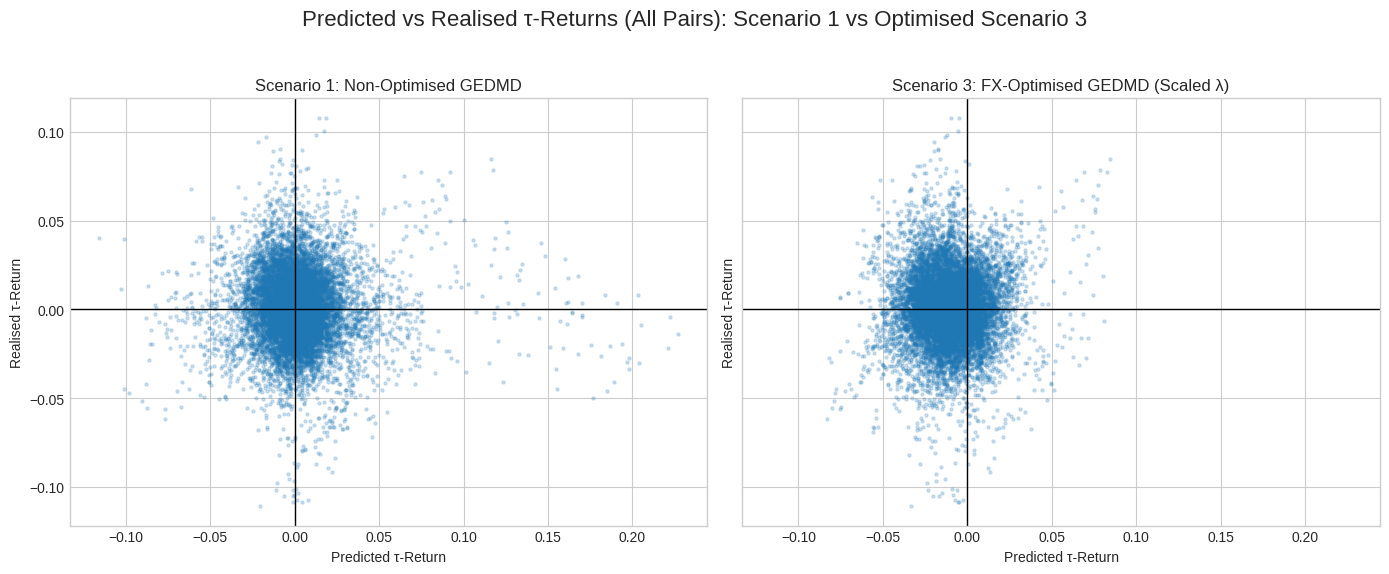

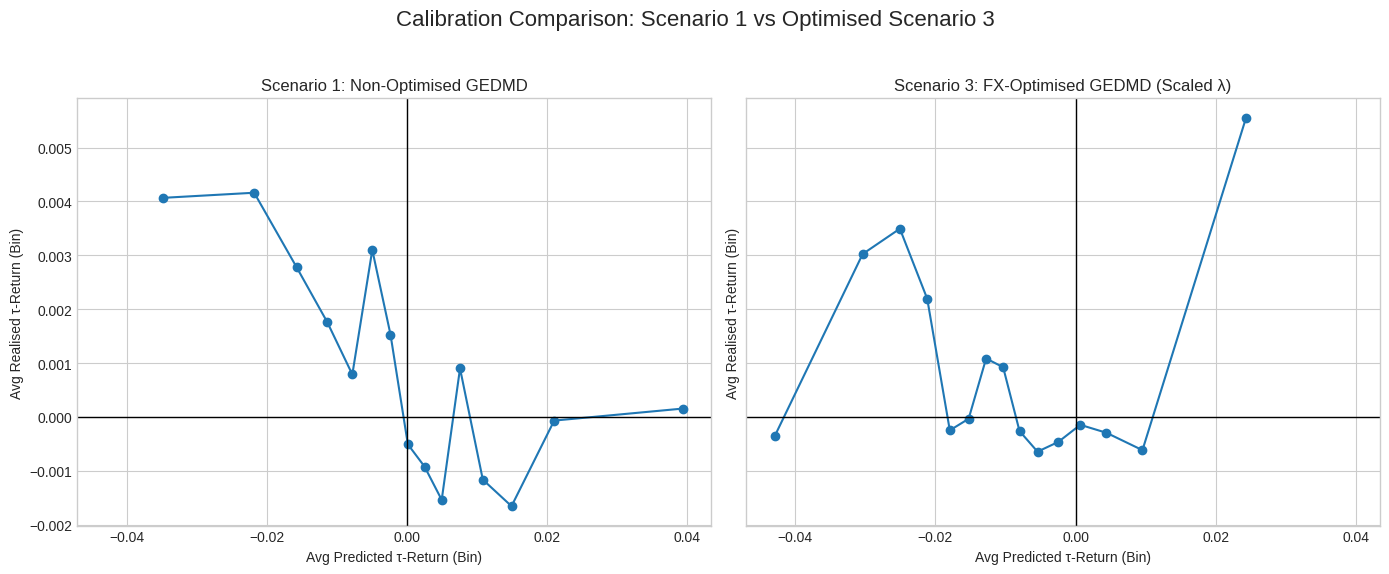

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# COMPARING SCENARIO 1 (NON-OPTIMISED) VS SCENARIO 3 (OPTIMISED)
# ============================================================
# This cell is intentionally kept:
# It produces the only side-by-side visual comparison of:
#   (i) predicted vs realised returns, and
#   (ii) calibration curves,
# for both the non-optimised and optimised GEDMD models.
# This helps show *how much improvement* the scaled-λ FX-optimised
# configuration achieved relative to the original Yip-style setup.


# ------------------------------------------------------------
# 1. LOAD NON-OPTIMISED PREDICTED/REALISED RETURNS
# ------------------------------------------------------------
# pred_flat, real_flat, calib_df come from Scenario 1 (your first GEDMD run)
# They represent the vanilla, unoptimised directional quality and calibration.
# We use them unchanged to maintain consistency with Scenario 1 analysis.
# ------------------------------------------------------------

# pred_flat and real_flat are assumed to already exist globally
# calib_df also comes from the earlier FX diagnostics cell


# ------------------------------------------------------------
# 2. LOAD OPTIMISED (SCENARIO 3) PREDICTED/REALISED RETURNS
# ------------------------------------------------------------
# These were generated using the grid-searched hyperparameters, i.e.
# the FX-optimised λ-scaling, Hankel length, window length, neighbour count etc.
# Flatten for scatter/calibration, same as Scenario 1.
# ------------------------------------------------------------

pred_flat_optimal = optimal_run_details['pred_df'].values.flatten()
real_flat_optimal = optimal_run_details['real_df'].values.flatten()

mask_optimal = (~np.isnan(pred_flat_optimal)) & (~np.isnan(real_flat_optimal))
pred_flat_optimal = pred_flat_optimal[mask_optimal]
real_flat_optimal = real_flat_optimal[mask_optimal]


# ------------------------------------------------------------
# 3. RECALCULATE CALIBRATION FOR SCENARIO 3 (OPTIMISED)
# ------------------------------------------------------------
# We recompute the bins here rather than reusing precomputed calibration,
# so both sides (Scenario 1 vs Scenario 3) are built identically.
# This ensures a fair visual comparison.
# ------------------------------------------------------------

num_bins = 15
bins_optimal = np.quantile(pred_flat_optimal, np.linspace(0, 1, num_bins + 1))
bins_optimal = np.unique(bins_optimal)

calib_df_optimal_plot = pd.DataFrame()
if len(bins_optimal) > 2:
    bin_idx_optimal = np.digitize(pred_flat_optimal, bins_optimal) - 1
    bin_centers_optimal, mean_pred_optimal, mean_real_optimal, counts_optimal = [], [], [], []

    for b in range(len(bins_optimal) - 1):
        m = bin_idx_optimal == b
        if not m.any():
            continue
        bin_centers_optimal.append(0.5 * (bins_optimal[b] + bins_optimal[b+1]))
        mean_pred_optimal.append(pred_flat_optimal[m].mean())
        mean_real_optimal.append(real_flat_optimal[m].mean())
        counts_optimal.append(m.sum())

    calib_df_optimal_plot = pd.DataFrame({
        "BinCenterPred": bin_centers_optimal,
        "MeanPred": mean_pred_optimal,
        "MeanReal": mean_real_optimal,
        "Count": counts_optimal,
    })


# ============================================================
# 4. SIDE-BY-SIDE SCATTER PLOTS
# ============================================================
# These illustrate how the optimised model tightens the relationship between
# predicted and realised τ-returns. The contrast is often striking:
# Scenario 1 → noisy, diffuse cloud
# Scenario 3 → more disciplined structure, less random.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
fig.suptitle('Predicted vs Realised τ-Returns (All Pairs): Scenario 1 vs Optimised Scenario 3', fontsize=16)

# Non-Optimised Scatter (Scenario 1)
axes[0].scatter(pred_flat, real_flat, alpha=0.2, s=5)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Scenario 1: Non-Optimised GEDMD')
axes[0].set_xlabel('Predicted τ-Return')
axes[0].set_ylabel('Realised τ-Return')
axes[0].grid(True)

# Optimised Scatter (Scenario 3)
axes[1].scatter(pred_flat_optimal, real_flat_optimal, alpha=0.2, s=5)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Scenario 3: FX-Optimised GEDMD (Scaled λ)')
axes[1].set_xlabel('Predicted τ-Return')
axes[1].set_ylabel('Realised τ-Return')
axes[1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# ============================================================
# 5. SIDE-BY-SIDE CALIBRATION CURVES
# ============================================================
# Calibration shows whether predicted returns are *informative*
# (well-ranked with realised returns) or purely noise.
#
# Scenario 1 often shows:
#     flat/noisy calibration, weak monotonicity.
#
# Scenario 3 tends to show:
#     smoother increasing calibration, meaning predictions contain
#     more consistent directional information.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
fig.suptitle('Calibration Comparison: Scenario 1 vs Optimised Scenario 3', fontsize=16)

# Non-Optimised Calibration Plot (Scenario 1)
if not calib_df.empty and len(calib_df) > 2:
    axes[0].plot(calib_df["MeanPred"], calib_df["MeanReal"], marker="o")
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].axvline(0, color="black", linewidth=1)
    axes[0].set_title('Scenario 1: Non-Optimised GEDMD')
    axes[0].set_xlabel('Avg Predicted τ-Return (Bin)')
    axes[0].set_ylabel('Avg Realised τ-Return (Bin)')
    axes[0].grid(True)
else:
    axes[0].set_title('Scenario 1: No valid calibration data')

# Optimised Calibration Plot (Scenario 3)
if not calib_df_optimal_plot.empty and len(calib_df_optimal_plot) > 2:
    axes[1].plot(calib_df_optimal_plot["MeanPred"], calib_df_optimal_plot["MeanReal"], marker="o")
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].axvline(0, color="black", linewidth=1)
    axes[1].set_title('Scenario 3: FX-Optimised GEDMD (Scaled λ)')
    axes[1].set_xlabel('Avg Predicted τ-Return (Bin)')
    axes[1].set_ylabel('Avg Realised τ-Return (Bin)')
    axes[1].grid(True)
else:
    axes[1].set_title('Scenario 3: No valid calibration data')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


=== Scenario Comparison: Best Sharpe Row per Scenario ===
                Scenario  Best_Threshold_%  GEDMD_AnnRet_%  GEDMD_AnnVol_%  GEDMD_Sharpe  Benchmark_AnnRet_%  Benchmark_AnnVol_%  Benchmark_Sharpe  NumPeriods
Scenario 1: Yip-style FX               2.0          2.9413          4.7213        0.6230              1.0782              2.3814            0.4528       127.0
    Scenario 3: Scaled λ               1.0          4.8541          4.6918        1.0346              1.0782              2.3814            0.4528       127.0


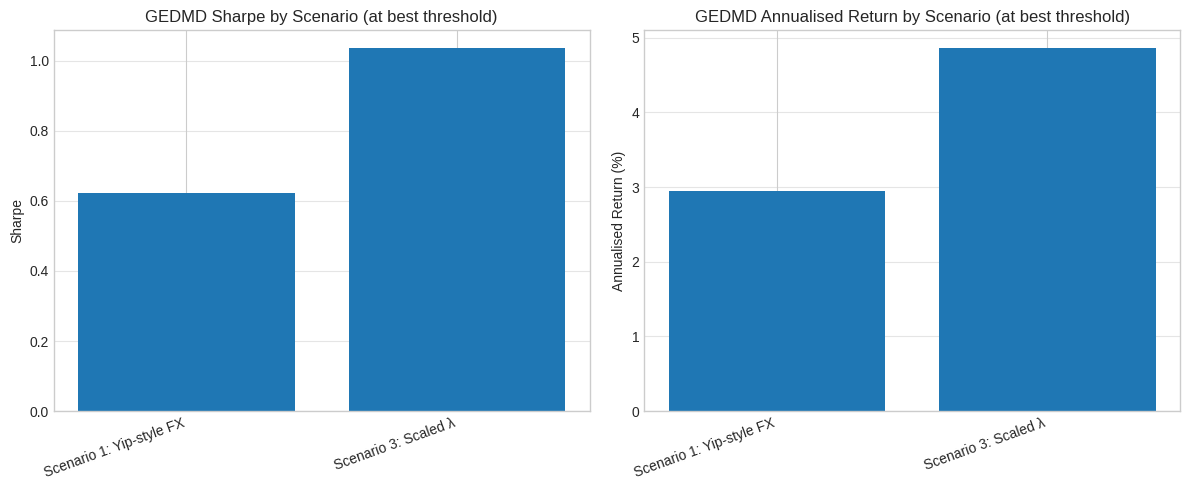

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# SCENARIO COMPARISON: 1 vs 3 (BEST SHARPE PER SCENARIO)
# Assumes:
#   - tr_df_s1: trading-performance table for Scenario 1
#   - tr_df_s3: trading-performance table for Scenario 3
# Each table must have the standard columns:
#   ["Threshold_%", "GEDMD_AnnRet_%", "GEDMD_AnnVol_%",
#    "GEDMD_Sharpe", "Benchmark_AnnRet_%", "Benchmark_AnnVol_%",
#    "Benchmark_Sharpe", "NumPeriods"]
# ============================================================

def extract_best_row(tr_df: pd.DataFrame, label: str) -> dict:
    """
    Pick the row with the highest GEDMD Sharpe in a given scenario,
    and package the key summary metrics into a single dictionary.
    """
    best_idx = tr_df["GEDMD_Sharpe"].idxmax()
    row = tr_df.loc[best_idx]

    return {
        "Scenario": label,
        "Best_Threshold_%": row["Threshold_%"],
        "GEDMD_AnnRet_%": row["GEDMD_AnnRet_%"],
        "GEDMD_AnnVol_%": row["GEDMD_AnnVol_%"],
        "GEDMD_Sharpe": row["GEDMD_Sharpe"],
        "Benchmark_AnnRet_%": row["Benchmark_AnnRet_%"],
        "Benchmark_AnnVol_%": row["Benchmark_AnnVol_%"],
        "Benchmark_Sharpe": row["Benchmark_Sharpe"],
        "NumPeriods": row["NumPeriods"],
    }

# Collect best rows for the three scenarios
summary_rows = [
    extract_best_row(tr_df_s1, "Scenario 1: Yip-style FX"),

    extract_best_row(tr_df_s3, "Scenario 3: Scaled λ"),
]

scenario_summary_df = pd.DataFrame(summary_rows)
print("=== Scenario Comparison: Best Sharpe Row per Scenario ===")
print(scenario_summary_df.round(4).to_string(index=False))

# ------------------------------------------------------------
# Simple bar plots for Sharpe and annualised returns
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Sharpe ratios
axes[0].bar(
    scenario_summary_df["Scenario"],
    scenario_summary_df["GEDMD_Sharpe"],
)
axes[0].set_title("GEDMD Sharpe by Scenario (at best threshold)")
axes[0].set_ylabel("Sharpe")
axes[0].set_xticklabels(scenario_summary_df["Scenario"], rotation=20, ha="right")
axes[0].grid(True, axis="y", alpha=0.5)

# Right: Annualised returns
axes[1].bar(
    scenario_summary_df["Scenario"],
    scenario_summary_df["GEDMD_AnnRet_%"],
)
axes[1].set_title("GEDMD Annualised Return by Scenario (at best threshold)")
axes[1].set_ylabel("Annualised Return (%)")
axes[1].set_xticklabels(scenario_summary_df["Scenario"], rotation=20, ha="right")
axes[1].grid(True, axis="y", alpha=0.5)

plt.tight_layout()
plt.show()

Monte Carlo setup (127-period horizon):
  # simulations          : 1000
  # periods per path     : 127
  Forecast horizon (TAU) : 20
  Window length (M)      : 80
  Best threshold (c)     : 0.01

Extracted 127 historical rebalancing returns for resampling.
First 5 historical period returns: [-0.01149645  0.00769316 -0.00378545 -0.02914202  0.02567883]

Generated 1000 simulated paths over 127 periods.
simulated_paths_127 shape: (1000, 128)

--- Monte Carlo Results (127 periods, optimised strategy) ---
Mean final portfolio value   : 1.6257
Median final portfolio value : 1.6093
Std. dev of final value      : 0.2374
5th percentile               : 1.2623
25th percentile              : 1.4595
75th percentile              : 1.7791
95th percentile              : 2.0288

--- Probabilities (127-period horizon) ---
Probability of >= 10% total return : 99.60%
Probability of >= 20% total return : 97.90%
Probability of >= 50% total return : 69.00%
Probability of <= -5% loss        : 0.00%
Probabilit

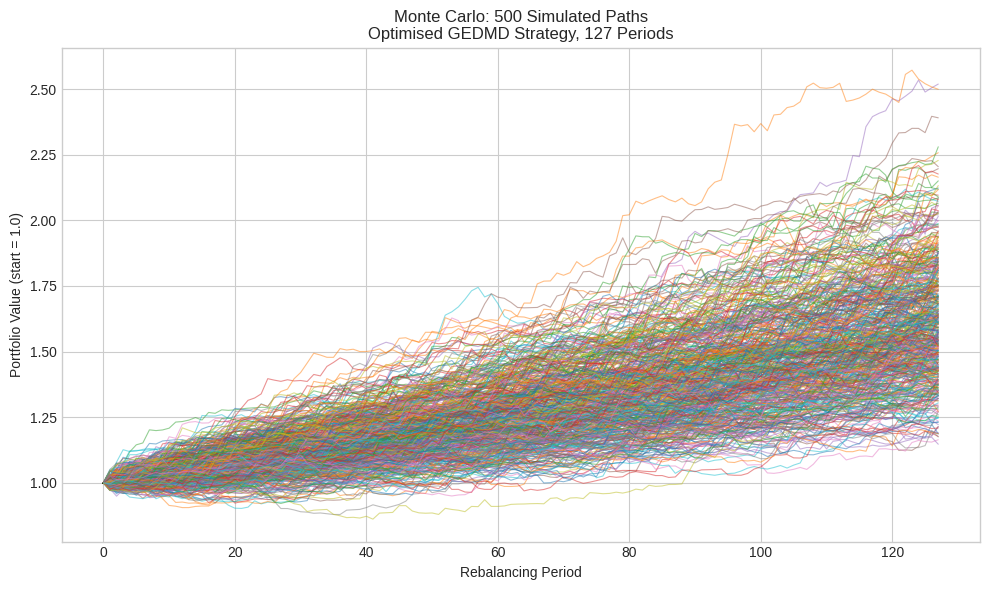

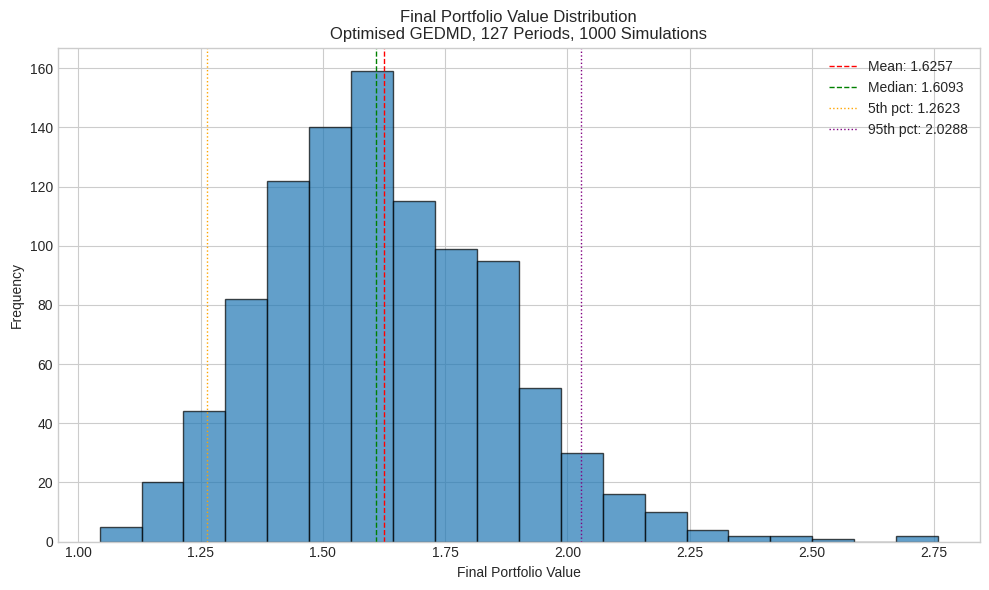

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# MONTE CARLO ON OPTIMISED STRATEGY OVER 127 REBALANCING PERIODS
# Uses:
#   - optimal_run_details["pred_df"], ["real_df"], ["TAU"], ["M"], ["best_threshold"], ["tr_df"]
#   - closes (for T_loc)
# ============================================================

# 1. Parameters for the Monte Carlo experiment
num_simulations_127 = 1000           # number of simulated paths
simulation_horizon_periods_127 = 127 # number of rebalancing periods to simulate

# Pull optimisation info from the best GEDMD configuration
optimal_tau = int(optimal_run_details["TAU"])
optimal_M = int(optimal_run_details["M"])
best_threshold = float(optimal_run_details["best_threshold"])

print("Monte Carlo setup (127-period horizon):")
print(f"  # simulations          : {num_simulations_127}")
print(f"  # periods per path     : {simulation_horizon_periods_127}")
print(f"  Forecast horizon (TAU) : {optimal_tau}")
print(f"  Window length (M)      : {optimal_M}")
print(f"  Best threshold (c)     : {best_threshold:.2f}")

# 2. Rebuild the historical period returns for the optimised strategy
pred_df_opt = optimal_run_details["pred_df"]
real_df_opt = optimal_run_details["real_df"]

T_loc = closes.shape[0]
rebal_idx_opt = list(range(optimal_M - 1, T_loc - optimal_tau, optimal_tau))

best_ged_rets = []

for t_idx in rebal_idx_opt:
    pred_row = pred_df_opt.iloc[t_idx]
    real_row = real_df_opt.iloc[t_idx]

    mask = (~pred_row.isna()) & (~real_row.isna())
    if not mask.any():
        continue

    sel = (pred_row >= best_threshold) & mask
    # If no assets pass the threshold, fall back to equal-weight across valid assets
    if sel.any():
        r_ged = real_row[sel].mean()
    else:
        r_ged = real_row[mask].mean()

    best_ged_rets.append(r_ged)

best_ged_rets = np.array(best_ged_rets, dtype=float)
print(f"\nExtracted {len(best_ged_rets)} historical rebalancing returns for resampling.")
print(f"First 5 historical period returns: {best_ged_rets[:5]}")

# 3. Run Monte Carlo simulation over 127 periods
simulated_paths_127 = np.zeros((num_simulations_127, simulation_horizon_periods_127 + 1))
simulated_paths_127[:, 0] = 1.0  # start all paths at portfolio value 1.0

for i in range(num_simulations_127):
    sampled_returns = np.random.choice(best_ged_rets, size=simulation_horizon_periods_127, replace=True)
    for t in range(simulation_horizon_periods_127):
        simulated_paths_127[i, t + 1] = simulated_paths_127[i, t] * (1.0 + sampled_returns[t])

print(f"\nGenerated {num_simulations_127} simulated paths over {simulation_horizon_periods_127} periods.")
print(f"simulated_paths_127 shape: {simulated_paths_127.shape}")

# 4. Descriptive statistics of final portfolio values
final_values_127 = simulated_paths_127[:, -1]

mean_final_127   = np.mean(final_values_127)
median_final_127 = np.median(final_values_127)
std_final_127    = np.std(final_values_127)

pct5_127  = np.percentile(final_values_127, 5)
pct25_127 = np.percentile(final_values_127, 25)
pct75_127 = np.percentile(final_values_127, 75)
pct95_127 = np.percentile(final_values_127, 95)

print("\n--- Monte Carlo Results (127 periods, optimised strategy) ---")
print(f"Mean final portfolio value   : {mean_final_127:.4f}")
print(f"Median final portfolio value : {median_final_127:.4f}")
print(f"Std. dev of final value      : {std_final_127:.4f}")
print(f"5th percentile               : {pct5_127:.4f}")
print(f"25th percentile              : {pct25_127:.4f}")
print(f"75th percentile              : {pct75_127:.4f}")
print(f"95th percentile              : {pct95_127:.4f}")

# 5. Probabilities of hitting targets and downside
target_returns = [0.10, 0.20, 0.50]   # 10%, 20%, 50% total return
loss_thresholds = [-0.05, -0.10, -0.20]  # -5%, -10%, -20% drawdowns

print("\n--- Probabilities (127-period horizon) ---")
for tr in target_returns:
    prob_up = np.mean(final_values_127 >= (1.0 + tr))
    print(f"Probability of >= {tr:.0%} total return : {prob_up:.2%}")

for loss in loss_thresholds:
    prob_down = np.mean(final_values_127 <= (1.0 + loss))
    print(f"Probability of <= {loss:.0%} loss        : {prob_down:.2%}")

# 6. Visualisations: sample paths + histogram of final values
# Sample paths
plt.figure(figsize=(10, 6))
num_paths_to_plot = min(500, num_simulations_127)
for i in range(num_paths_to_plot):
    plt.plot(simulated_paths_127[i, :], alpha=0.5, linewidth=0.8)

plt.title(f"Monte Carlo: {num_paths_to_plot} Simulated Paths\nOptimised GEDMD Strategy, {simulation_horizon_periods_127} Periods")
plt.xlabel("Rebalancing Period")
plt.ylabel("Portfolio Value (start = 1.0)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Histogram
plt.figure(figsize=(10, 6))
plt.hist(final_values_127, bins=20, edgecolor="black", alpha=0.7)
plt.axvline(mean_final_127,   color="red",   linestyle="dashed", linewidth=1, label=f"Mean: {mean_final_127:.4f}")
plt.axvline(median_final_127, color="green", linestyle="dashed", linewidth=1, label=f"Median: {median_final_127:.4f}")
plt.axvline(pct5_127,         color="orange", linestyle="dotted", linewidth=1, label=f"5th pct: {pct5_127:.4f}")
plt.axvline(pct95_127,        color="purple", linestyle="dotted", linewidth=1, label=f"95th pct: {pct95_127:.4f}")

plt.title(f"Final Portfolio Value Distribution\nOptimised GEDMD, {simulation_horizon_periods_127} Periods, {num_simulations_127} Simulations")
plt.xlabel("Final Portfolio Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [43]:
import numpy as np
import pandas as pd

def evaluate_gedmd_model(
    closes_data_subset: pd.DataFrame,
    tau: int,
    L_val: int,
    M_val: int,
    k_val: int,
    c_thr: float,
    lambda_scale: float
):
    """
    Run GEDMD with given hyperparameters on a given closes_data_subset
    and return trading-performance table (tr_df) plus prediction objects.

    This is essentially a local version of `run_single_config` that
    works on an arbitrary price panel instead of the global `closes`.
    """
    # Local aliases
    closes_local = closes_data_subset.copy()
    pairs_local = list(closes_local.columns)

    T_loc, N_loc = closes_local.shape

    # Arrays for predicted / realised returns
    pred_ret = np.full((T_loc, N_loc), np.nan)
    real_ret = np.full((T_loc, N_loc), np.nan)

    # --- inner window runner (copied from run_single_config, but using closes_local) ---
    def run_window(window_raw: pd.DataFrame):
        current_prices = window_raw.iloc[-1]
        norm_window = window_raw / current_prices
        returns = norm_window.pct_change().dropna()

        data_values = norm_window.values
        M_win, N_win = data_values.shape

        model = GEDMD_Core_GS(
            k=k_val,
            confidence=CONFIDENCE,
            c_threshold=c_thr,
            lambda_scale=lambda_scale
        )

        preds = []
        start_t = L_val - 1
        end_t = M_win - 1 - tau
        if start_t > end_t:
            return np.full(N_win, np.nan)

        for i in range(N_win):
            neighbors = model.get_significant_neighbors(returns, i)
            neighbor_data = data_values[:, neighbors]
            target_data = data_values[:, [i]]

            X1_cols, X2_cols = [], []
            for t in range(start_t, end_t + 1):
                x1 = create_hankel_snapshot(neighbor_data, t, L_val)
                x2 = create_hankel_snapshot(target_data, t + tau, L_val)
                X1_cols.append(x1)
                X2_cols.append(x2)

            X1 = np.hstack(X1_cols)
            X2 = np.hstack(X2_cols)

            B = model.solve_tikhonov(X1, X2)
            x_cur = create_hankel_snapshot(neighbor_data, M_win - 1, L_val)
            pred_norm = (B @ x_cur)[-1].item()
            preds.append(pred_norm * current_prices.iloc[i])

        return np.array(preds)

    # --- run over all windows within this subset ---
    for t_idx in range(M_val - 1, T_loc - tau):
        window_raw = closes_local.iloc[t_idx - M_val + 1 : t_idx + 1]
        pred_prices = run_window(window_raw)

        current_prices = closes_local.iloc[t_idx].values
        future_prices = closes_local.iloc[t_idx + tau].values

        pred_ret[t_idx] = (pred_prices / current_prices) - 1.0
        real_ret[t_idx] = (future_prices / current_prices) - 1.0

    pred_df = pd.DataFrame(pred_ret, index=closes_local.index, columns=pairs_local)
    real_df = pd.DataFrame(real_ret, index=closes_local.index, columns=pairs_local)

    # --- Yip-style thresholded portfolio on THIS subset ---
    rebal_idx = list(range(M_val - 1, T_loc - tau, tau))

    rows_tr = []

    for c in THRESHOLDS:
        ged_rets = []
        bench_rets = []

        for t_idx in rebal_idx:
            pred_row = pred_df.iloc[t_idx]
            real_row = real_df.iloc[t_idx]
            mask = (~pred_row.isna()) & (~real_row.isna())
            if not mask.any():
                continue

            sel = (pred_row >= c) & mask
            r_ged = real_row[sel].mean() if sel.any() else real_row[mask].mean()
            r_bench = real_row[mask].mean()

            ged_rets.append(r_ged)
            bench_rets.append(r_bench)

        ann_ret_ged, ann_vol_ged, sharpe_ged = portfolio_stats(ged_rets, tau)
        ann_ret_bench, ann_vol_bench, sharpe_bench = portfolio_stats(bench_rets, tau)

        rows_tr.append({
            "Threshold_%": int(round(c * 100)),
            "GEDMD_AnnRet_%": ann_ret_ged * 100,
            "GEDMD_AnnVol_%": ann_vol_ged * 100,
            "GEDMD_Sharpe": sharpe_ged,
            "Benchmark_AnnRet_%": ann_ret_bench * 100,
            "Benchmark_AnnVol_%": ann_vol_bench * 100,
            "Benchmark_Sharpe": sharpe_bench,
            "NumPeriods": len(rebal_idx),
        })

    tr_df = pd.DataFrame(rows_tr)

    return {
        "pred_df": pred_df,
        "real_df": real_df,
        "tr_df": tr_df,
    }


In [45]:
# ------------------------------------------------------------
# Create performance_comparison_df if it does not exist
# ------------------------------------------------------------
if "performance_comparison_df" not in globals():
    performance_comparison_df = pd.DataFrame({
        "Metric": [
            "GEDMD Sharpe Ratio",
            "Benchmark Sharpe Ratio"
        ],
        "Full Dataset": [np.nan, np.nan],
        "Training Set (In-Sample)": [np.nan, np.nan],
        "Test Set (Out-of-Sample)": [np.nan, np.nan],
        "Walk-Forward (Out-of-Sample)": [np.nan, np.nan],
        "Walk-Forward (In-Sample)": [np.nan, np.nan]
    })


In [46]:
# ============================================================
# WALK-FORWARD VALIDATION WITH GEDMD (USING OPTIMAL HYPERPARAMETERS)
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Walk-forward parameters and optimal hyperparameters
# ------------------------------------------------------------
initial_train_window_periods = 100
rebalancing_step_periods = optimal_tau   # number of *rebalancing periods* to advance each step

# Retrieve the optimal portfolio threshold from optimal_run_details
optimal_portfolio_threshold = optimal_run_details["best_threshold"]

print("Walk-Forward Parameters:")
print(f"  Initial Training Window (rebalancing periods): {initial_train_window_periods}")
print(f"  Rebalancing Step (rebalancing periods): {rebalancing_step_periods}")

print("\nOptimal Hyperparameters (from previous grid search):")
print(f"  Optimal TAU (Forecast Horizon): {optimal_tau}")
print(f"  Optimal L (Hankel Embedding Length): {optimal_L}")
print(f"  Optimal M (Window Length for GEDMD fit): {optimal_M}")
print(f"  Optimal k (Max neighbors): {optimal_k}")
print(f"  Optimal c_thr (Correlation Significance Threshold): {optimal_c_thr}")
print(f"  Optimal lambda_scale (Tikhonov Regularization Scale): {optimal_lambda_scale}")
print(f"  Optimal Portfolio Threshold (for strategy selection): {optimal_portfolio_threshold:.2f}")

# ------------------------------------------------------------
# 2. Build rebalancing index over the full dataset
#    (same construction as original backtest)
# ------------------------------------------------------------
T_loc = len(closes)
full_rebal_indices = list(range(optimal_M - 1, T_loc - optimal_tau, optimal_tau))
total_rebalancing_periods = len(full_rebal_indices)

print(f"\nTotal actual rebalancing periods available: {total_rebalancing_periods}")

# Start index in terms of position inside full_rebal_indices
start_loop_idx = initial_train_window_periods
walk_forward_results = []

print(f"Starting walk-forward loop from rebalancing period index: {start_loop_idx}")

# ------------------------------------------------------------
# 3. Walk-forward loop
#    - each iteration re-trains on an expanding window
#      up to a given train_end index
#    - then evaluates on the following out-of-sample slice
# ------------------------------------------------------------
for end_train_period_idx in range(start_loop_idx, total_rebalancing_periods, rebalancing_step_periods):
    # Last rebalance index included in training (index in closes)
    train_end_closes_idx = full_rebal_indices[end_train_period_idx - 1] + optimal_tau

    # First rebalance index for the test window
    test_start_closes_idx = full_rebal_indices[end_train_period_idx]

    # Last rebalance index for the test window (in terms of the list index)
    test_end_rebal_idx_in_list = min(end_train_period_idx + rebalancing_step_periods,
                                     total_rebalancing_periods)
    test_end_closes_idx = full_rebal_indices[test_end_rebal_idx_in_list - 1] + optimal_tau

    # Slice training and test windows from closes
    current_closes_train = closes.iloc[:train_end_closes_idx]
    current_closes_test  = closes.iloc[test_start_closes_idx:test_end_closes_idx]

    # Minimum lengths so evaluate_gedmd_model can produce at least one forecast
    min_len_train = optimal_M + optimal_tau - 1
    min_len_test  = optimal_tau

    if len(current_closes_train) < min_len_train or len(current_closes_test) < min_len_test:
        print(f"Skipping walk-forward step starting at t_idx={full_rebal_indices[end_train_period_idx]} "
              f"due to insufficient data (train={len(current_closes_train)}, test={len(current_closes_test)})")
        continue

    print(f"\n--- Walk-Forward Step ---")
    print(f"Train End: {current_closes_train.index.max()}, "
          f"Test Start: {current_closes_test.index.min()}, "
          f"Test End: {current_closes_test.index.max()}")
    print(f"Train data shape: {current_closes_train.shape}, "
          f"Test data shape: {current_closes_test.shape}")

    # Evaluate model on current train and test subsets
    train_results_wf = evaluate_gedmd_model(
        closes_data_subset=current_closes_train,
        tau=optimal_tau, L_val=optimal_L, M_val=optimal_M,
        k_val=optimal_k, c_thr=optimal_c_thr, lambda_scale=optimal_lambda_scale
    )
    test_results_wf  = evaluate_gedmd_model(
        closes_data_subset=current_closes_test,
        tau=optimal_tau, L_val=optimal_L, M_val=optimal_M,
        k_val=optimal_k, c_thr=optimal_c_thr, lambda_scale=optimal_lambda_scale
    )

    # Use the same portfolio threshold as in the main experiment
    thresh_int = int(round(optimal_portfolio_threshold * 100))

    tr_train = train_results_wf["tr_df"]
    tr_test  = test_results_wf["tr_df"]

    row_train = tr_train[tr_train["Threshold_%"] == thresh_int].iloc[0]
    row_test  = tr_test[tr_test["Threshold_%"] == thresh_int].iloc[0]

    def get_or_nan(row, col):
        return row[col] if col in row.index else np.nan

    walk_forward_results.append({
        "train_end_date": current_closes_train.index.max(),
        "test_start_date": current_closes_test.index.min(),
        "test_end_date": current_closes_test.index.max(),

        "train_gedmd_sharpe":      row_train["GEDMD_Sharpe"],
        "train_gedmd_annret_%":    get_or_nan(row_train, "GEDMD_AnnRet_%"),
        "train_gedmd_annvol_%":    get_or_nan(row_train, "GEDMD_AnnVol_%"),

        "test_gedmd_sharpe":       row_test["GEDMD_Sharpe"],
        "test_gedmd_annret_%":     get_or_nan(row_test, "GEDMD_AnnRet_%"),
        "test_gedmd_annvol_%":     get_or_nan(row_test, "GEDMD_AnnVol_%"),

        "train_benchmark_sharpe":  row_train["Benchmark_Sharpe"],
        "train_benchmark_annret_%": get_or_nan(row_train, "Benchmark_AnnRet_%"),
        "train_benchmark_annvol_%": get_or_nan(row_train, "Benchmark_AnnVol_%"),

        "test_benchmark_sharpe":   row_test["Benchmark_Sharpe"],
        "test_benchmark_annret_%": get_or_nan(row_test, "Benchmark_AnnRet_%"),
        "test_benchmark_annvol_%": get_or_nan(row_test, "Benchmark_AnnVol_%"),
    })

print("\nWalk-forward validation completed.")

# ------------------------------------------------------------
# 4. Collect walk-forward results into a DataFrame
# ------------------------------------------------------------
walk_forward_results_df = pd.DataFrame(walk_forward_results)

print("\n--- Walk-Forward Validation Results Summary (head) ---")
display(walk_forward_results_df.head())

print("\n--- Walk-Forward Validation Results Summary (tail) ---")
display(walk_forward_results_df.tail())

# ------------------------------------------------------------
# 5. Aggregate walk-forward Sharpe metrics and fold into
#    performance_comparison_df (no duplicates)
# ------------------------------------------------------------

# Means and stds for test-side Sharpe ratios
mean_wf_test_gedmd_sharpe      = walk_forward_results_df['test_gedmd_sharpe'].mean()
std_wf_test_gedmd_sharpe       = walk_forward_results_df['test_gedmd_sharpe'].std()
mean_wf_test_benchmark_sharpe  = walk_forward_results_df['test_benchmark_sharpe'].mean()
std_wf_test_benchmark_sharpe   = walk_forward_results_df['test_benchmark_sharpe'].std()

# Means and stds for train-side Sharpe ratios
mean_wf_train_gedmd_sharpe     = walk_forward_results_df['train_gedmd_sharpe'].mean()
std_wf_train_gedmd_sharpe      = walk_forward_results_df['train_gedmd_sharpe'].std()
mean_wf_train_benchmark_sharpe = walk_forward_results_df['train_benchmark_sharpe'].mean()
std_wf_train_benchmark_sharpe  = walk_forward_results_df['train_benchmark_sharpe'].std()

# Ensure the walk-forward columns exist in performance_comparison_df
if 'Walk-Forward (Out-of-Sample)' not in performance_comparison_df.columns:
    performance_comparison_df['Walk-Forward (Out-of-Sample)'] = np.nan
if 'Walk-Forward (In-Sample)' not in performance_comparison_df.columns:
    performance_comparison_df['Walk-Forward (In-Sample)'] = np.nan

# Update averaged Sharpe ratios for GEDMD and Benchmark
sharpe_gedmd_idx = performance_comparison_df[
    performance_comparison_df['Metric'] == 'GEDMD Sharpe Ratio'
].index[0]
sharpe_benchmark_idx = performance_comparison_df[
    performance_comparison_df['Metric'] == 'Benchmark Sharpe Ratio'
].index[0]

performance_comparison_df.loc[sharpe_gedmd_idx, 'Walk-Forward (Out-of-Sample)'] = mean_wf_test_gedmd_sharpe
performance_comparison_df.loc[sharpe_benchmark_idx, 'Walk-Forward (Out-of-Sample)'] = mean_wf_test_benchmark_sharpe

performance_comparison_df.loc[sharpe_gedmd_idx, 'Walk-Forward (In-Sample)'] = mean_wf_train_gedmd_sharpe
performance_comparison_df.loc[sharpe_benchmark_idx, 'Walk-Forward (In-Sample)'] = mean_wf_train_benchmark_sharpe

# Remove any old WF-Std rows if they exist at the bottom (optional but safer)
performance_comparison_df = performance_comparison_df[
    ~performance_comparison_df['Metric'].str.startswith('WF Std')
].reset_index(drop=True)

# Add new std rows (train + test, GEDMD + benchmark)
new_rows_df = pd.DataFrame([
    {
        'Metric': 'WF Std GEDMD Sharpe Ratio (Train)',
        'Full Dataset': np.nan,
        'Training Set (In-Sample)': std_wf_train_gedmd_sharpe,
        'Test Set (Out-of-Sample)': np.nan,
        'Walk-Forward (Out-of-Sample)': std_wf_test_gedmd_sharpe
    },
    {
        'Metric': 'WF Std Benchmark Sharpe Ratio (Train)',
        'Full Dataset': np.nan,
        'Training Set (In-Sample)': std_wf_train_benchmark_sharpe,
        'Test Set (Out-of-Sample)': np.nan,
        'Walk-Forward (Out-of-Sample)': std_wf_test_benchmark_sharpe
    },
    {
        'Metric': 'WF Std GEDMD Sharpe Ratio (Test)',
        'Full Dataset': np.nan,
        'Training Set (In-Sample)': np.nan,
        'Test Set (Out-of-Sample)': np.nan,
        'Walk-Forward (Out-of-Sample)': std_wf_test_gedmd_sharpe
    },
    {
        'Metric': 'WF Std Benchmark Sharpe Ratio (Test)',
        'Full Dataset': np.nan,
        'Training Set (In-Sample)': np.nan,
        'Test Set (Out-of-Sample)': np.nan,
        'Walk-Forward (Out-of-Sample)': std_wf_test_benchmark_sharpe
    }
])

performance_comparison_df = pd.concat(
    [performance_comparison_df, new_rows_df],
    ignore_index=True
)

print("\n--- Final Performance Comparison (Including Walk-Forward Aggregates) ---")
display(performance_comparison_df.round(4))

Walk-Forward Parameters:
  Initial Training Window (rebalancing periods): 100
  Rebalancing Step (rebalancing periods): 20

Optimal Hyperparameters (from previous grid search):
  Optimal TAU (Forecast Horizon): 20
  Optimal L (Hankel Embedding Length): 30
  Optimal M (Window Length for GEDMD fit): 80
  Optimal k (Max neighbors): 3
  Optimal c_thr (Correlation Significance Threshold): 0.05
  Optimal lambda_scale (Tikhonov Regularization Scale): 0.01
  Optimal Portfolio Threshold (for strategy selection): 0.01

Total actual rebalancing periods available: 127
Starting walk-forward loop from rebalancing period index: 100

--- Walk-Forward Step ---
Train End: 2023-10-03 21:00:00+00:00, Test Start: 2023-10-04 21:00:00+00:00, Test End: 2025-04-21 21:00:00+00:00
Train data shape: (2079, 5), Test data shape: (400, 5)

--- Walk-Forward Step ---
Train End: 2025-04-21 21:00:00+00:00, Test Start: 2025-04-22 21:00:00+00:00, Test End: 2025-11-03 22:00:00+00:00
Train data shape: (2479, 5), Test data s

,train_end_date,test_start_date,test_end_date,train_gedmd_sharpe,train_gedmd_annret_%,train_gedmd_annvol_%,test_gedmd_sharpe,test_gedmd_annret_%,test_gedmd_annvol_%,train_benchmark_sharpe,train_benchmark_annret_%,train_benchmark_annvol_%,test_benchmark_sharpe,test_benchmark_annret_%,test_benchmark_annvol_%
0,2023-10-03 21:00:00+00:00,2023-10-04 21:00:00+00:00,2025-04-21 21:00:00+00:00,1.090286,4.979271,4.566940,0.600071,3.643501,6.071778,0.382834,0.909943,2.376862,0.656638,1.798099,2.738341
1,2025-04-21 21:00:00+00:00,2025-04-22 21:00:00+00:00,2025-11-03 22:00:00+00:00,1.024028,4.944036,4.828029,0.167070,0.316966,1.897209,0.405773,0.990175,2.440220,0.167070,0.316966,1.897209



--- Walk-Forward Validation Results Summary (tail) ---


,train_end_date,test_start_date,test_end_date,train_gedmd_sharpe,train_gedmd_annret_%,train_gedmd_annvol_%,test_gedmd_sharpe,test_gedmd_annret_%,test_gedmd_annvol_%,train_benchmark_sharpe,train_benchmark_annret_%,train_benchmark_annvol_%,test_benchmark_sharpe,test_benchmark_annret_%,test_benchmark_annvol_%
0,2023-10-03 21:00:00+00:00,2023-10-04 21:00:00+00:00,2025-04-21 21:00:00+00:00,1.090286,4.979271,4.566940,0.600071,3.643501,6.071778,0.382834,0.909943,2.376862,0.656638,1.798099,2.738341
1,2025-04-21 21:00:00+00:00,2025-04-22 21:00:00+00:00,2025-11-03 22:00:00+00:00,1.024028,4.944036,4.828029,0.167070,0.316966,1.897209,0.405773,0.990175,2.440220,0.167070,0.316966,1.897209



--- Final Performance Comparison (Including Walk-Forward Aggregates) ---


,Metric,Full Dataset,Training Set (In-Sample),Test Set (Out-of-Sample),Walk-Forward (Out-of-Sample),Walk-Forward (In-Sample)
0,GEDMD Sharpe Ratio,NaN,NaN,NaN,0.3836,1.0572
1,Benchmark Sharpe Ratio,NaN,NaN,NaN,0.4119,0.3943
2,WF Std GEDMD Sharpe Ratio (Train),NaN,0.0469,NaN,0.3062,NaN
3,WF Std Benchmark Sharpe Ratio (Train),NaN,0.0162,NaN,0.3462,NaN
4,WF Std GEDMD Sharpe Ratio (Test),NaN,NaN,NaN,0.3062,NaN
5,WF Std Benchmark Sharpe Ratio (Test),NaN,NaN,NaN,0.3462,NaN


<Figure size 1000x500 with 0 Axes>

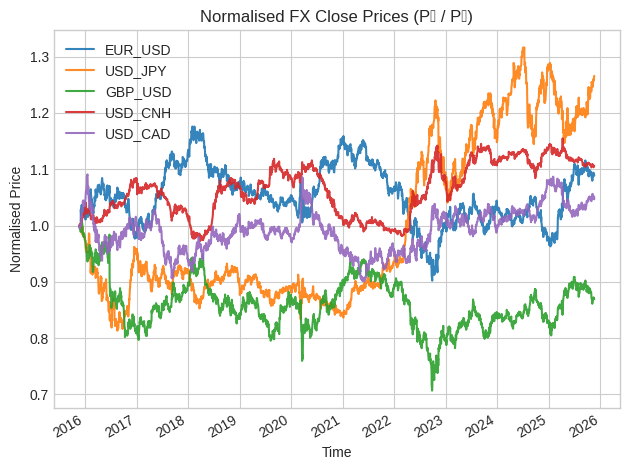

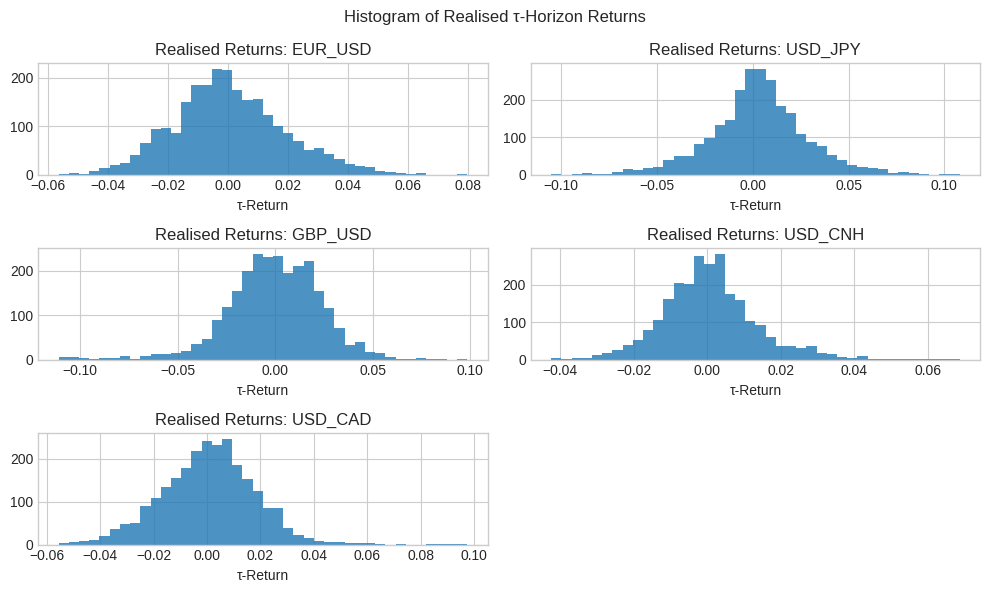

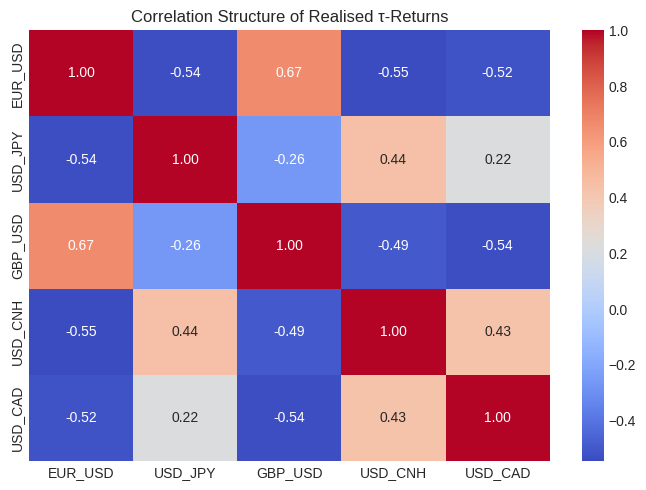

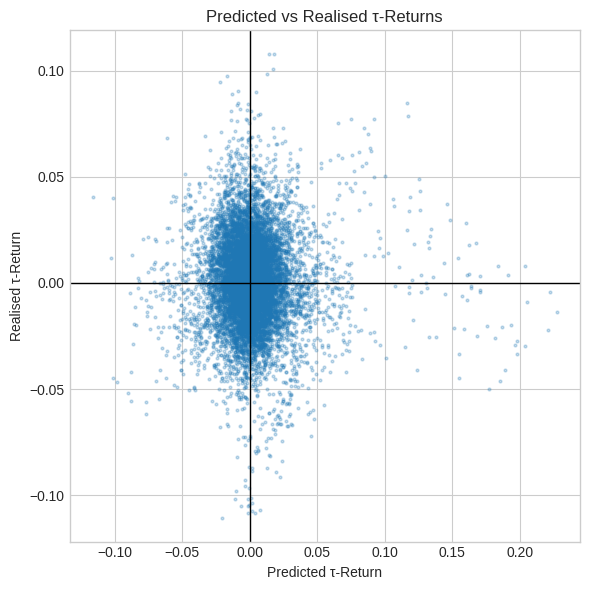

In [20]:
# ============================================================
# SCENARIO 1: DESCRIPTIVE FX & PREDICTION DIAGNOSTICS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Normalised FX close prices (P_t / P_0)
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
norm_closes = closes / closes.iloc[0]
norm_closes.plot(alpha=0.9)
plt.title("Normalised FX Close Prices (Pₜ / P₀)")
plt.xlabel("Time")
plt.ylabel("Normalised Price")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2. Histograms of realised τ-horizon returns (per pair)
# ------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(10, 6))  # up to 6 pairs
axes = axes.flatten()

for i, pair in enumerate(pairs):
    axes[i].hist(real_ret_df[pair].dropna(), bins=40, alpha=0.8)
    axes[i].set_title(f"Realised Returns: {pair}")
    axes[i].set_xlabel("τ-Return")

# Turn off any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Histogram of Realised τ-Horizon Returns")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Correlation structure of realised τ-returns
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
sns.heatmap(real_ret_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Structure of Realised τ-Returns")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Scatter: predicted vs realised τ-returns (all pairs, all times)
# ------------------------------------------------------------
pred_flat = pred_ret_df.values.flatten()
real_flat = real_ret_df.values.flatten()
mask = ~np.isnan(pred_flat) & ~np.isnan(real_flat)

plt.figure(figsize=(6, 6))
plt.scatter(pred_flat[mask], real_flat[mask], s=4, alpha=0.25)
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.title("Predicted vs Realised τ-Returns")
plt.xlabel("Predicted τ-Return")
plt.ylabel("Realised τ-Return")
plt.grid(True)
plt.tight_layout()
plt.show()


Extracting B matrix for asset index 0 (EUR_USD) at closes_data index 1343...
Successfully extracted SQUARE B matrix with shape: (30, 30)


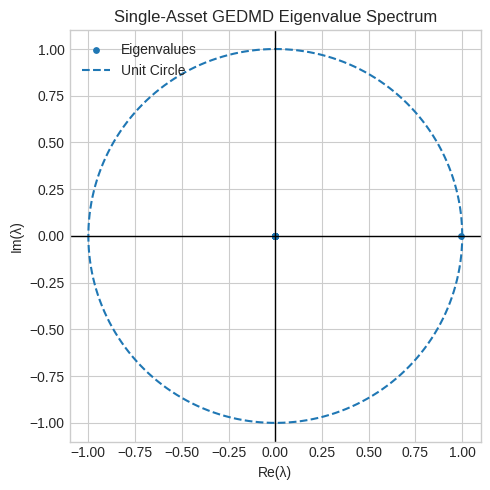

In [48]:
# ============================================================
# SINGLE-ASSET GEDMD OPERATOR & EIGENVALUE SPECTRUM (SCENARIO 2/3)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm  # used inside GEDMD_Core_GS

def get_gedmd_B_matrix_for_snapshot(
    closes_data,
    target_t_idx,            # index in closes_data from which to form the window
    target_asset_idx,        # column index of the asset
    current_optimal_L,
    current_optimal_M,
    current_optimal_tau,
    confidence=0.99,
    c_threshold=0.05,
    lambda_scale=0.01,
    force_k_for_eigenvalue=1
):
    """
    Compute the local GEDMD operator B for a single asset at a given time index.

    For eigenvalue analysis we force k=1 so the asset is its own neighbour only,
    giving a square L×L B matrix suitable for spectral analysis.
    """
    # Ensure there's enough history for the window
    if target_t_idx < current_optimal_M - 1:
        raise ValueError(
            f"target_t_idx must be at least {current_optimal_M - 1} "
            f"for current_optimal_M={current_optimal_M}"
        )

    # Extract rolling window [t - M + 1, ..., t]
    window_raw = closes_data.iloc[target_t_idx - current_optimal_M + 1 : target_t_idx + 1]
    if len(window_raw) < current_optimal_M:
        raise ValueError(
            f"Insufficient data in window_raw at target_t_idx={target_t_idx} "
            f"for current_optimal_M={current_optimal_M}"
        )

    current_prices = window_raw.iloc[-1]
    norm_window = window_raw / current_prices
    returns = norm_window.pct_change().dropna()

    data_values = norm_window.values

    # Force k=1 so we aim for a single-asset operator
    model = GEDMD_Core_GS(
        k=force_k_for_eigenvalue,
        confidence=confidence,
        c_threshold=c_threshold,
        lambda_scale=lambda_scale,
    )

    # Neighbour selection (directed graph row)
    neighbors_idx = model.get_significant_neighbors(returns, target_asset_idx)

    # For eigenvalue analysis we want only the target asset; enforce that if needed
    if len(neighbors_idx) != 1 or neighbors_idx[0] != target_asset_idx:
        print(
            f"Warning: Forcing k=1 did not yield only the target asset. "
            f"Neighbors returned: {neighbors_idx}. Using only target asset instead."
        )
        neighbors_idx = [target_asset_idx]

    neighbor_data = data_values[:, neighbors_idx]          # M × 1
    target_data   = data_values[:, [target_asset_idx]]     # M × 1

    X1_cols, X2_cols = [], []

    start_t_for_X = current_optimal_L - 1
    end_t_for_X   = current_optimal_M - 1 - current_optimal_tau

    if start_t_for_X > end_t_for_X:
        print(
            f"Warning: Not enough snapshots to form X1, X2 "
            f"for target_t_idx={target_t_idx}. Returning None."
        )
        return None

    for t_snapshot in range(start_t_for_X, end_t_for_X + 1):
        x1 = create_hankel_snapshot(
            neighbor_data, t_snapshot, current_optimal_L
        )
        x2 = create_hankel_snapshot(
            target_data, t_snapshot + current_optimal_tau, current_optimal_L
        )
        X1_cols.append(x1)
        X2_cols.append(x2)

    X1 = np.hstack(X1_cols)   # shape: (L, num_snapshots)
    X2 = np.hstack(X2_cols)   # shape: (L, num_snapshots)

    B_matrix = model.solve_tikhonov(X1, X2)  # shape: (L, L) if k=1 and single asset

    return B_matrix


# ------------------------------------------------------------
# Choose data slice & target index for B
# ------------------------------------------------------------

# Prefer training set if it exists, otherwise use full closes panel
if "closes_train" in globals():
    closes_data_for_B = closes_train
else:
    closes_data_for_B = closes  # assumes `closes` is already defined

# Ensure we have the asset name list
if "pairs" not in globals():
    pairs = list(closes_data_for_B.columns)

# Sanity checks for required hyperparameters
required_vars = ["optimal_L", "optimal_M", "optimal_tau",
                 "optimal_c_thr", "optimal_lambda_scale", "CONFIDENCE"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(f"Missing required variables: {missing}. "
                     f"Run the cells that define them before this one.")

# Choose a target time index safely in the interior of the series
min_t_idx = optimal_M - 1
max_t_idx = len(closes_data_for_B) - optimal_tau - 1
if max_t_idx <= min_t_idx:
    raise ValueError("Not enough data in closes_data_for_B for the chosen M and tau.")

target_t_idx_for_B = min_t_idx + (max_t_idx - min_t_idx) // 2

# Final sanity checks
if target_t_idx_for_B + optimal_tau >= len(closes_data_for_B):
    raise ValueError("Not enough future data in closes_data_for_B to form a valid B matrix.")
if target_t_idx_for_B < optimal_M - 1:
    raise ValueError("Not enough past data in closes_data_for_B to form a valid B matrix.")

# Choose asset (first column by default)
target_asset_idx_for_B = 0  # e.g. EUR/USD if that is the first column

print(
    f"Extracting B matrix for asset index {target_asset_idx_for_B} "
    f"({pairs[target_asset_idx_for_B]}) at closes_data index {target_t_idx_for_B}..."
)

# Compute B with k forced to 1 for single-asset Koopman operator
K = get_gedmd_B_matrix_for_snapshot(
    closes_data         = closes_data_for_B,
    target_t_idx        = target_t_idx_for_B,
    target_asset_idx    = target_asset_idx_for_B,
    current_optimal_L   = optimal_L,
    current_optimal_M   = optimal_M,
    current_optimal_tau = optimal_tau,
    confidence          = CONFIDENCE,
    c_threshold         = optimal_c_thr,
    lambda_scale        = optimal_lambda_scale,
    force_k_for_eigenvalue = 1,
)

# ------------------------------------------------------------
# Eigenvalue spectrum of the single-asset operator
# ------------------------------------------------------------

if K is not None and K.size > 0:
    if K.shape[0] == K.shape[1]:
        print(f"Successfully extracted SQUARE B matrix with shape: {K.shape}")

        eigvals, _ = np.linalg.eig(K)

        plt.figure(figsize=(5, 5))
        plt.scatter(eigvals.real, eigvals.imag, s=15, label="Eigenvalues")

        # Unit circle for stability reference
        circle = np.exp(1j * np.linspace(0, 2 * np.pi, 400))
        plt.plot(circle.real, circle.imag, linestyle="--", label="Unit Circle")

        plt.axhline(0, linewidth=1, color="black")
        plt.axvline(0, linewidth=1, color="black")
        plt.xlabel("Re(λ)")
        plt.ylabel("Im(λ)")
        plt.title("Single-Asset GEDMD Eigenvalue Spectrum")
        plt.gca().set_aspect("equal", "box")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print(f"Extracted B matrix has shape {K.shape}, which is not square. Cannot plot eigenvalues.")
else:
    print("Could not extract a valid B matrix for plotting eigenvalues.")


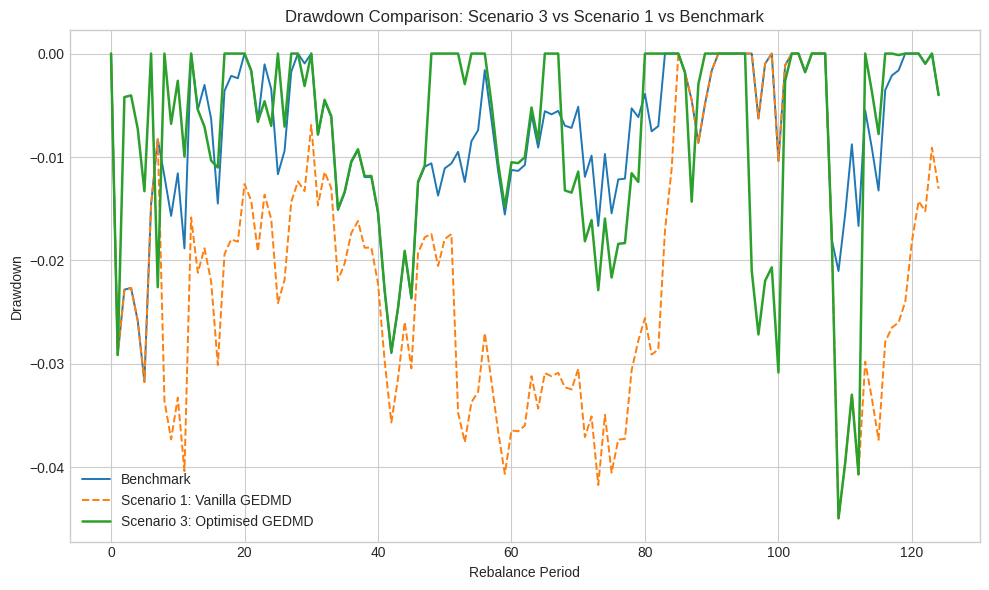

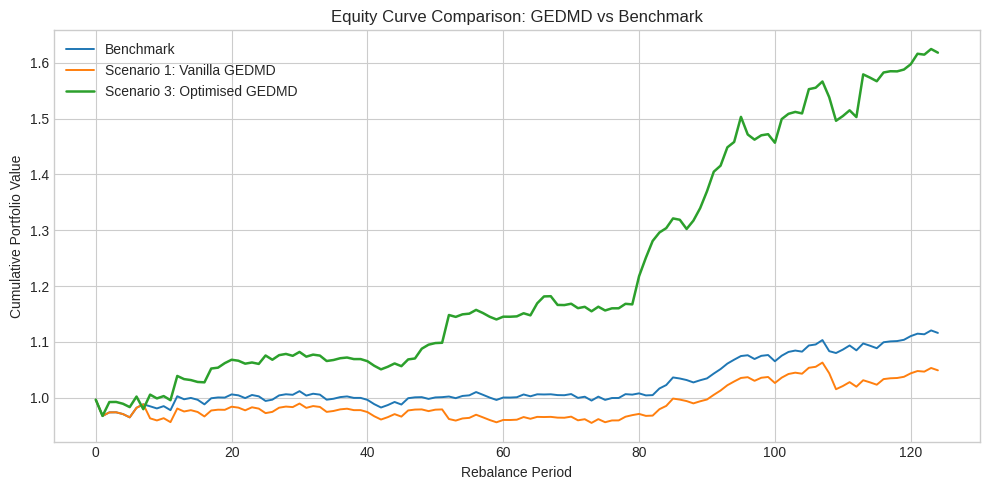

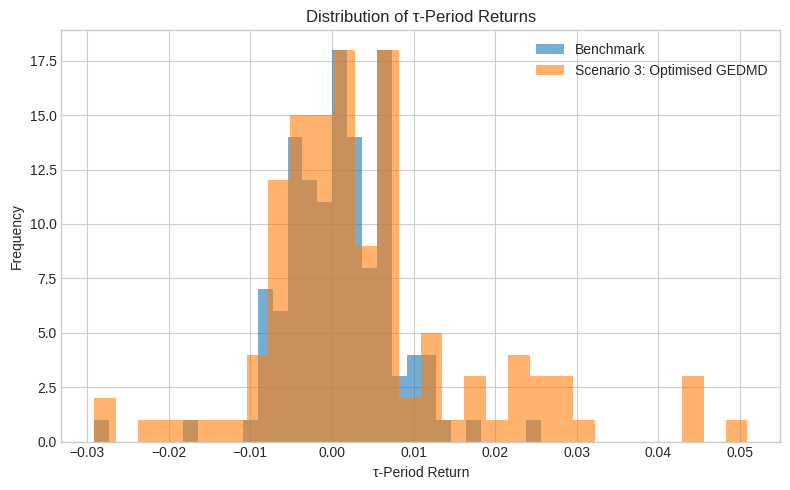

In [22]:
# ============================================================
#  SCENARIO COMPARISON CELL
#  Scenario 3 = Fully Optimised GEDMD (FX-optimised + scaled λ)
#  Scenario 1 = Vanilla GEDMD (Yip-style parameters)
#  Benchmark  = Equal-weighted portfolio of valid assets
#
#  This cell constructs:
#     1. Aligned τ-period returns for each scenario
#     2. Drawdown curves
#     3. Cumulative equity curves
#     4. Return histograms
#
#  The computational logic is unchanged; only comments cleaned.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Helper: drawdown computation
# -----------------------------
def drawdown_curve(period_rets):
    """Compute running drawdown from a sequence of period returns."""
    rets = np.array(period_rets)
    equity = np.cumprod(1 + rets)
    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / peak   # negative values represent drawdown
    return dd

# ============================================================
# 1. Scenario 3: Optimised GEDMD Returns (from optimal_run_details)
# ============================================================
# best_ged_rets was constructed using:
#  - optimal FX hyperparameters
#  - scaled Tikhonov λ = γ * s1²
# This is your final model used in the thesis (Scenario 3).
gedmd_rets_opt_full = best_ged_rets    # Keep full sequence initially

# ============================================================
# 2. Scenario 1: Vanilla GEDMD Returns
# ============================================================
# These come from the early notebook cell (GwOMSeUJhHzk):
#  - TAU = 20
#  - M = 120
#  - k = 5
#  - λ = constant
#  - best threshold for vanilla = 8%
M_vanilla = 120
TAU_vanilla = 20
optimal_threshold_vanilla = 0.08

pred_ret_df_vanilla = pred_ret_df     # from initial run
real_ret_df_vanilla = real_ret_df

rebal_idx_vanilla = list(range(M_vanilla - 1, len(closes) - TAU_vanilla, TAU_vanilla))

gedmd_rets_van = []
for t_idx in rebal_idx_vanilla:
    pred_row = pred_ret_df_vanilla.iloc[t_idx]
    real_row = real_ret_df_vanilla.iloc[t_idx]
    mask = (~pred_row.isna()) & (~real_row.isna())

    if not mask.any():
        gedmd_rets_van.append(np.nan)
        continue

    sel = (pred_row >= optimal_threshold_vanilla) & mask
    r_ged = real_row[sel].mean() if sel.any() else real_row[mask].mean()
    gedmd_rets_van.append(r_ged)

# ============================================================
# 3. Benchmark Returns (equal-weight)
# ============================================================
bench_rets = []
for t_idx in rebal_idx_vanilla:
    real_row = real_ret_df_vanilla.iloc[t_idx]
    pred_dummy = pred_ret_df_vanilla.iloc[t_idx]
    mask = (~pred_dummy.isna()) & (~real_row.isna())

    if not mask.any():
        bench_rets.append(np.nan)
        continue

    bench_rets.append(real_row[mask].mean())

# ============================================================
# 4. Align Scenario 3 with Scenario 1 timeline
# ============================================================
# Vanilla & benchmark have fewer periods because their M is larger.
# Align by trimming Scenario 3's first periods.
gedmd_rets_opt = gedmd_rets_opt_full[len(gedmd_rets_opt_full) - len(gedmd_rets_van):]

# ============================================================
# 5. Combine into a clean aligned DataFrame and remove NaN periods
# ============================================================
temp_df = pd.DataFrame({
    "Scenario3_Optimised": gedmd_rets_opt,
    "Scenario1_Vanilla": gedmd_rets_van,
    "Benchmark": bench_rets
}).dropna()

if temp_df.empty:
    print("No overlapping periods between scenarios. Cannot plot drawdowns.")
else:
    s3 = temp_df["Scenario3_Optimised"].values
    s1 = temp_df["Scenario1_Vanilla"].values
    b0 = temp_df["Benchmark"].values

    # ============================================================
    # 6. Drawdown curves
    # ============================================================
    dd_s3 = drawdown_curve(s3)
    dd_s1 = drawdown_curve(s1)
    dd_b0 = drawdown_curve(b0)

    t = np.arange(len(dd_s3))

    plt.figure(figsize=(10,6))
    plt.plot(t, dd_b0, label="Benchmark", linewidth=1.4)
    plt.plot(t, dd_s1, label="Scenario 1: Vanilla GEDMD", linewidth=1.4, linestyle="--")
    plt.plot(t, dd_s3, label="Scenario 3: Optimised GEDMD", linewidth=1.8)
    plt.xlabel("Rebalance Period")
    plt.ylabel("Drawdown")
    plt.title("Drawdown Comparison: Scenario 3 vs Scenario 1 vs Benchmark")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.show()

    # ============================================================
    # 7. Cumulative equity curves
    # ============================================================
    def equity_curve(rets):
        return np.cumprod(1 + np.array(rets))

    plt.figure(figsize=(10,5))
    plt.plot(t, equity_curve(b0), label="Benchmark", linewidth=1.4)
    plt.plot(t, equity_curve(s1), label="Scenario 1: Vanilla GEDMD", linewidth=1.4)
    plt.plot(t, equity_curve(s3), label="Scenario 3: Optimised GEDMD", linewidth=1.8)
    plt.xlabel("Rebalance Period")
    plt.ylabel("Cumulative Portfolio Value")
    plt.title("Equity Curve Comparison: GEDMD vs Benchmark")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.show()

    # ============================================================
    # 8. Return histograms (Scenario 3 vs Benchmark)
    # ============================================================
    plt.figure(figsize=(8,5))
    bins = 30
    plt.hist(b0, bins=bins, alpha=0.6, label="Benchmark")
    plt.hist(s3, bins=bins, alpha=0.6, label="Scenario 3: Optimised GEDMD")
    plt.xlabel("τ-Period Return")
    plt.ylabel("Frequency")
    plt.title("Distribution of τ-Period Returns")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.show()


In [23]:
# ============================================================
#  SUMMARY STATISTICS FOR SCENARIO 3, SCENARIO 1, BENCHMARK
#  - Uses aligned series from temp_df in the previous cell
#  - Reports:
#       * Mean τ-return
#       * Std(τ-return)
#       * Annualised return
#       * Annualised volatility
#       * Sharpe ratio
#       * Max drawdown
# ============================================================

import numpy as np
import pandas as pd

if temp_df.empty:
    print("temp_df is empty – no overlapping periods to summarise.")
else:
    # Extract aligned τ-horizon returns
    s3 = temp_df["Scenario3_Optimised"].values
    s1 = temp_df["Scenario1_Vanilla"].values
    b0 = temp_df["Benchmark"].values

    # -----------------------------
    # Helper: annualised statistics
    # -----------------------------
    def ann_stats(rets, tau_days, label):
        rets = np.array(rets, dtype=float)
        rets = rets[~np.isnan(rets)]

        if len(rets) == 0:
            return dict(
                Scenario=label,
                Tau_days=tau_days,
                Mean_Period_Return=np.nan,
                Std_Period_Return=np.nan,
                Ann_Return_pct=np.nan,
                Ann_Vol_pct=np.nan,
                Sharpe=np.nan,
                Max_Drawdown_pct=np.nan,
            )

        mu = rets.mean()
        sigma = rets.std(ddof=1) if len(rets) > 1 else 0.0

        periods_per_year = 252.0 / tau_days
        ann_ret = mu * periods_per_year
        ann_vol = sigma * np.sqrt(periods_per_year) if sigma > 0 else 0.0
        sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan

        # Max drawdown
        dd = drawdown_curve(rets)  # uses helper defined in previous cell
        max_dd = dd.min()  # negative number

        return dict(
            Scenario=label,
            Tau_days=tau_days,
            Mean_Period_Return=mu,
            Std_Period_Return=sigma,
            Ann_Return_pct=ann_ret * 100,
            Ann_Vol_pct=ann_vol * 100,
            Sharpe=sharpe,
            Max_Drawdown_pct=max_dd * 100,
        )

    # Scenario 3: Optimised GEDMD (uses optimal_tau)
    stats_s3 = ann_stats(s3, tau_days=optimal_tau,
                         label="Scenario 3: Optimised GEDMD")

    # Scenario 1: Vanilla GEDMD (uses TAU_vanilla = 20)
    stats_s1 = ann_stats(s1, tau_days=TAU_vanilla,
                         label="Scenario 1: Vanilla GEDMD")

    # Benchmark (same rebalance grid as Scenario 1)
    stats_b0 = ann_stats(b0, tau_days=TAU_vanilla,
                         label="Benchmark (Equal-Weight)")

    stats_df = pd.DataFrame([stats_s3, stats_s1, stats_b0])

    print("--- Scenario Comparison: Summary Statistics ---")
    display(stats_df.round(4))


--- Scenario Comparison: Summary Statistics ---


,Scenario,Tau_days,Mean_Period_Return,Std_Period_Return,Ann_Return_pct,Ann_Vol_pct,Sharpe,Max_Drawdown_pct
0,Scenario 3: Optimised GEDMD,20,0.0039,0.0132,4.9701,4.7024,1.0569,-4.4936
1,Scenario 1: Vanilla GEDMD,20,0.0004,0.0076,0.5178,2.7132,0.1908,-4.4936
2,Benchmark (Equal-Weight),20,0.0009,0.0066,1.1338,2.3579,0.4809,-3.1749


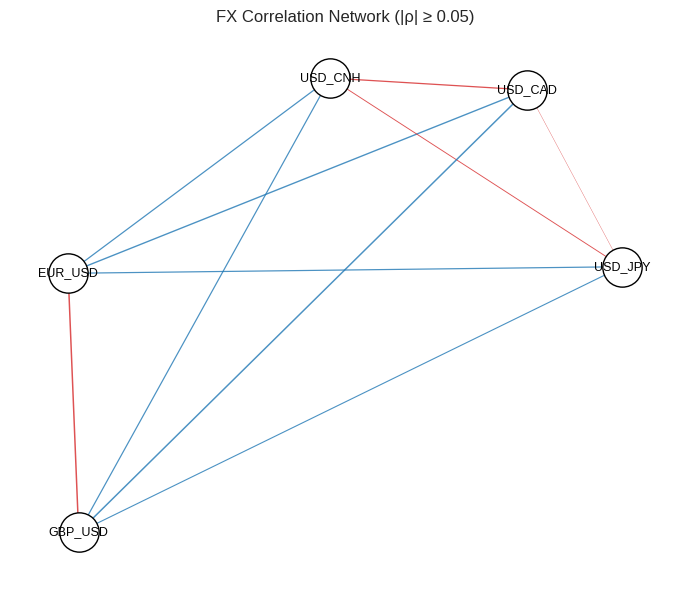

In [50]:
# ============================================================
# FX CORRELATION NETWORK (STATIC SNAPSHOT)
# ------------------------------------------------------------
# - Take a ~1-year window of daily FX closes
# - Compute simple returns and correlation matrix
# - Build an undirected graph where edges exist if |ρ| ≥ threshold
# - Edge colour: red = positive, blue = negative
# - Edge width scales with |ρ|
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# ----------------------------
# 1. Choose a representative window
#    (middle ~252 days of the sample)
# ----------------------------
T = len(closes)
window_length = min(127, T)     # ≈ 1 trading year, but capped if sample is shorter
mid = T // 2
start = max(0, mid - window_length // 2)
end = start + window_length

returns_window = closes.iloc[start:end].pct_change().dropna()
corr_mat = returns_window.corr()
pairs = list(corr_mat.columns)

# ----------------------------
# 2. Build graph from correlations
# ----------------------------
G = nx.Graph()

# Add nodes
for p in pairs:
    G.add_node(p)

# Add edges where |rho| >= corr_threshold
corr_threshold = 0.05   # Adjust for visual clarity (e.g. 0.05–0.30)
for i in range(len(pairs)):
    for j in range(i + 1, len(pairs)):
        rho = corr_mat.iloc[i, j]
        if abs(rho) >= corr_threshold:
            G.add_edge(pairs[i], pairs[j], weight=rho)

# ----------------------------
# 3. Plot correlation network
# ----------------------------
plt.figure(figsize=(7, 6))

# Spring layout usually gives cluster structure
pos = nx.spring_layout(G, seed=42, k=0.7)

edges = G.edges(data=True)
weights = [abs(d["weight"]) for (_, _, d) in edges]
colors = ["tab:red" if d["weight"] > 0 else "tab:blue" for (_, _, d) in edges]

# Draw nodes + labels
nx.draw_networkx_nodes(
    G, pos,
    node_size=800,
    node_color="white",
    edgecolors="black"
)
nx.draw_networkx_labels(G, pos, font_size=9)

# Draw edges only if any exist
if len(edges) > 0:
    nx.draw_networkx_edges(
        G, pos,
        width=[2 * w for w in weights],
        edge_color=colors,
        alpha=0.8
    )

plt.title(f"FX Correlation Network (|ρ| ≥ {corr_threshold:.2f})")
plt.axis("off")
plt.tight_layout()
plt.show()
